# Stage 03 - Characteristic CPU Solver Experiments v1

This notebook extends the stable baseline CPU solver from Stage 02 by testing more wave-aware boundary conditions based on local characteristic impedance.

The goal is to improve pressure-wave propagation through the ADAN-86 arterial network, especially the waveform measured in the right brachial artery.

This notebook compares:

- baseline vessel connection coupling
- fast characteristic vessel connection coupling
- baseline Windkessel terminal boundary conditions
- fast characteristic Windkessel terminal boundary conditions
- optional phenomenological flow damping

The main target is not only numerical stability.  
The main target is to produce a more plausible peripheral arterial waveform, with:

- visible delay relative to the aortic root
- realistic pressure range
- reduced non-physical oscillations
- usable brachial waveform shape for the final animation

The notebook uses the parsed ADAN network from Stage 01:

```python
adan_parsed.pkl

## Imports & Setup

In [1]:
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import trapezoid


# Load parsed ADAN data
with open("adan_parsed.pkl", "rb") as f:
    adan = pickle.load(f)

globals().update(adan)

print("Loaded ADAN parsed data")
print("Vessels:", len(order))
print("Topology rows:", len(topology_df))
print("Terminals:", len(terminal_idx))
print("Root:", root_idx, [order[i] for i in root_idx])


# Load valid baseline for comparison

with open("results/baseline_p90_cpu_cfl01_v1.pkl", "rb") as f:
    baseline_cpu = pickle.load(f)

print("\nLoaded baseline:")
print("mode:", baseline_cpu["mode"])
print("dt:", baseline_cpu["dt"])
print("brachial pressure range:",
      baseline_cpu["validation"]["brachial_pressure_min_mmHg"],
      baseline_cpu["validation"]["brachial_pressure_max_mmHg"])

Loaded ADAN parsed data
Vessels: 103
Topology rows: 102
Terminals: 43
Root: [0] ['ascending_aorta_C0']

Loaded baseline:
mode: baseline_cpu_reconstructed
dt: 3.220877998788529e-05
brachial pressure range: 89.06309950005365 122.7356504557686


## Common physics helper functions

This section defines the basic physical conversions used throughout the solver.

The solver evolves:

```text
A = cross-sectional area
Q = volumetric flow

In [ ]:
def area_to_pressure(A, A0, beta):
    """
    Convert vessel cross-sectional area to pressure using the elastic wall law.

    The model assumes:

        P = beta * (sqrt(A) - sqrt(A0))

    where:
        - A is the current lumen area,
        - A0 is the reference (unstressed) area,
        - beta controls vessel stiffness.

    Larger area corresponds to higher pressure because the compliant
    vessel wall expands under load.

    Args:
        A: Current vessel area [m²].
        A0: Reference vessel area [m²].
        beta: Vessel stiffness parameter [Pa / sqrt(m²)].

    Returns:
        Pressure relative to the reference state [Pa].
    """
    A_safe = np.maximum(A, 1e-14)
    return beta * (np.sqrt(A_safe) - np.sqrt(A0))


def pressure_to_area(P, A0, beta):
    """
    Convert pressure to vessel area using the inverse elastic wall law.

    Inverts:

        P = beta * (sqrt(A) - sqrt(A0))

    to recover vessel area from pressure.

    This is used when boundary conditions prescribe pressure and the
    solver must reconstruct the corresponding vessel expansion.

    Args:
        P: Pressure relative to the reference state [Pa].
        A0: Reference vessel area [m²].
        beta: Vessel stiffness parameter.

    Returns:
        Vessel cross-sectional area [m²].
    """
    sqrt_A = P / beta + np.sqrt(A0)
    sqrt_A = np.maximum(sqrt_A, 1e-14)
    return sqrt_A**2


def local_wave_speed(A, A0, beta, rho=RHO):
    """
    Compute local pulse wave propagation speed.

    For the wall law:

        P = beta * (sqrt(A) - sqrt(A0))

    the corresponding wave speed is:

        c² = A/rho * dP/dA
           = beta * sqrt(A) / (2*rho)

    Physiologically:
        - stiffer vessels -> faster waves,
        - larger vessels -> faster waves,
        - higher density -> slower waves.

    Args:
        A: Current vessel area [m²].
        A0: Reference vessel area [m²].
        beta: Vessel stiffness parameter.
        rho: Blood density [kg/m³].

    Returns:
        Local pulse wave velocity [m/s].
    """
    A_safe = np.maximum(A, 1e-14)
    return np.sqrt(beta * np.sqrt(A_safe) / (2.0 * rho))


def local_characteristic_impedance(A, A0, beta, rho=RHO):
    """
    Compute local characteristic impedance of the vessel.

    The characteristic impedance is:

        Z = rho * c / A

    where:
        - c is local wave speed,
        - A is vessel area.

    Physiologically, impedance describes how strongly the vessel
    resists pulsatile flow and determines how pressure and flow
    waves interact at bifurcations and boundaries.

    Higher impedance means:
        - larger pressure changes for a given flow,
        - stronger wave reflections.

    Args:
        A: Current vessel area [m²].
        A0: Reference vessel area [m²].
        beta: Vessel stiffness parameter.
        rho: Blood density [kg/m³].

    Returns:
        Characteristic impedance [Pa·s/m³].
    """
    A_safe = np.maximum(A, 1e-14)
    c = local_wave_speed(A_safe, A0, beta, rho)
    return rho * c / A_safe

## Synthetic cardiac inflow waveform

The heart is represented as a prescribed inflow waveform at the aortic root.

No cardiac chambers or valves are modeled in this notebook.  
Instead, the root vessel receives a synthetic one-second cardiac cycle with:

- systolic ejection
- a broad systolic peak
- a small late-systolic shoulder
- a small negative recoil after systole
- calibrated stroke volume

The waveform is scaled so that the integral over one cycle equals the target stroke volume.

This provides a repeatable input signal for comparing different boundary-condition strategies.

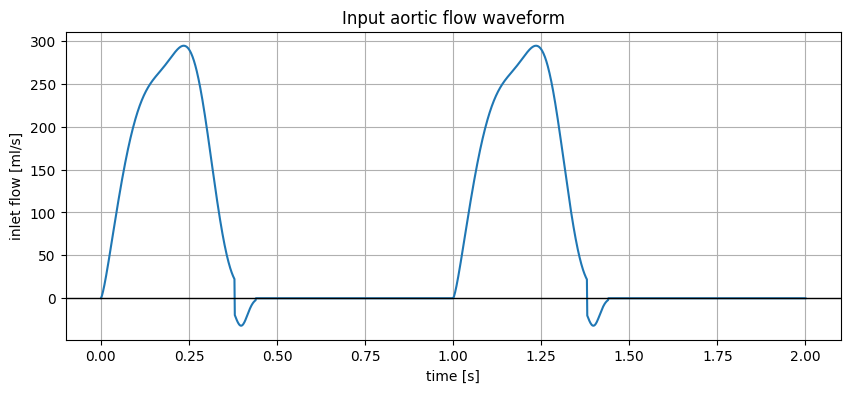

Q peak [ml/s]: 294.398723353155
Q min [ml/s]: -32.0334664240778
SV [ml]: 69.98942574610462


In [ ]:
T_CARDIAC = 1.0
T_SYS = 0.38

STROKE_VOLUME_ML = 70.0
STROKE_VOLUME = STROKE_VOLUME_ML * 1e-6


def inlet_shape_raw(tau):
    """
    Define the dimensionless aortic inlet waveform for one cardiac cycle.

    The waveform has three parts:
    - a main systolic ejection pulse,
    - a small systolic shoulder,
    - a short negative recoil after systole.

    This function only defines waveform shape. It is later scaled so that
    one cardiac cycle integrates to the target stroke volume.

    Args:
        tau: Time within one cardiac cycle [s].

    Returns:
        Dimensionless inlet-flow amplitude.
    """
    if tau < 0.0:
        return 0.0

    if tau < T_SYS:
        x = tau / T_SYS

        a = 1.4
        b = 2.2

        main = (x ** a) * ((1.0 - x) ** b)

        shoulder = 0.06 * np.exp(
            -0.5 * ((tau - 0.27) / 0.055) ** 2
        )

        return main + shoulder

    elif tau < T_SYS + 0.06:
        return -0.012 * np.exp(
            -0.5 * ((tau - (T_SYS + 0.018)) / 0.018) ** 2
        )

    else:
        return 0.0


ts_cal = np.linspace(0, T_CARDIAC, 3000)
shape = np.array([inlet_shape_raw(t) for t in ts_cal])
area_shape = trapezoid(shape, ts_cal)

Q_SCALE = STROKE_VOLUME / area_shape


def inlet_flow(t):
    """
    Compute the physical aortic inlet flow at simulation time t.

    Converts global simulation time into cardiac-cycle phase and scales
    the raw dimensionless waveform to match the prescribed stroke volume.

    Args:
        t: Simulation time [s].

    Returns:
        Aortic inlet flow rate [m³/s].
    """
    tau = t % T_CARDIAC
    return Q_SCALE * inlet_shape_raw(tau)


ts = np.linspace(0, 2.0, 2000)
qs = np.array([inlet_flow(t) for t in ts])

plt.figure(figsize=(10, 4))
plt.plot(ts, qs * 1e6)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("time [s]")
plt.ylabel("inlet flow [ml/s]")
plt.title("Input aortic flow waveform")
plt.grid(True)
plt.show()

print("Q peak [ml/s]:", qs.max() * 1e6)
print("Q min [ml/s]:", qs.min() * 1e6)
print("SV [ml]:", trapezoid(qs[ts < 1.0], ts[ts < 1.0]) * 1e6)

## Initialization, MacCormack update, and stabilizer

The solver starts from a uniform reference pressure of:

```python
P_REF = 90 mmHg

In [ ]:
P_REF = 90.0 * MMHG
P_VENOUS = 5.0 * MMHG

ROOT_IDX = int(root_idx[0]) if np.ndim(root_idx) > 0 else int(root_idx)

CFL_SOLVER = 0.10
dt_global = CFL_SOLVER * np.min(dxv / c0v)

A_ref_v = np.array([
    pressure_to_area(P_REF, A0v[i], betav[i])
    for i in range(len(A0v))
])

print("ROOT_IDX:", ROOT_IDX, order[ROOT_IDX])
print("dt_global:", dt_global)
print("n_steps 2s:", int(2.0 / dt_global))
print("A_ref/A0 range:", np.min(A_ref_v / A0v), np.max(A_ref_v / A0v))


def initialize_state(A0v, betav, Nv, P_init):
    """
    Initialize all vessels at uniform pressure and zero flow.

    Each vessel starts from the same pressure state. The pressure is
    converted to area using the inverse wall law, while flow is initialized
    to zero everywhere.

    Args:
        A0v: Reference area per vessel [m²].
        betav: Wall stiffness parameter per vessel.
        Nv: Number of grid points per vessel.
        P_init: Initial pressure [Pa].

    Returns:
        (A, Q)
        A: List of initialized area arrays.
        Q: List of initialized flow arrays.
    """
    A = []
    Q = []

    for i in range(len(A0v)):
        A_init = pressure_to_area(P_init, A0v[i], betav[i])
        A.append(np.full(Nv[i], A_init, dtype=float))
        Q.append(np.zeros(Nv[i], dtype=float))

    return A, Q


def compute_flux(A, Q, A0, beta, rho=RHO):
    """
    Compute flux terms for the 1D blood-flow equations.

    Conservative variables are:

        U = [A, Q]

    Fluxes are:

        F1 = Q
        F2 = Q²/A + P(A)A/rho

    Args:
        A: Vessel area array [m²].
        Q: Flow array [m³/s].
        A0: Reference vessel area [m²].
        beta: Wall stiffness parameter.
        rho: Blood density [kg/m³].

    Returns:
        (F1, F2) flux arrays.
    """
    A_safe = np.maximum(A, 1e-12)

    P = area_to_pressure(A_safe, A0, beta)

    F1 = Q
    F2 = Q**2 / A_safe + P * A_safe / rho

    return F1, F2


def maccormack_step(A, Q, A0, beta, dx, dt):
    """
    Advance one vessel by one MacCormack predictor-corrector step.

    The MacCormack method first predicts the next state using a forward
    spatial difference, then corrects it using a backward spatial difference.

    Boundary points are handled outside this function.

    Args:
        A: Vessel area array [m²].
        Q: Flow array [m³/s].
        A0: Reference vessel area [m²].
        beta: Wall stiffness parameter.
        dx: Spatial grid spacing [m].
        dt: Time step [s].

    Returns:
        Updated (A_new, Q_new) arrays.
    """
    N = len(A)

    if N < 3:
        return A, Q

    A_new = A.copy()
    Q_new = Q.copy()

    F1, F2 = compute_flux(A, Q, A0, beta)

    A_pred = A.copy()
    Q_pred = Q.copy()

    A_pred[:-1] = A[:-1] - dt / dx * (F1[1:] - F1[:-1])
    Q_pred[:-1] = Q[:-1] - dt / dx * (F2[1:] - F2[:-1])

    A_pred = np.maximum(A_pred, 1e-12)

    F1p, F2p = compute_flux(A_pred, Q_pred, A0, beta)

    A_new[1:] = 0.5 * (
        A[1:] + A_pred[1:] - dt / dx * (F1p[1:] - F1p[:-1])
    )

    Q_new[1:] = 0.5 * (
        Q[1:] + Q_pred[1:] - dt / dx * (F2p[1:] - F2p[:-1])
    )

    A_new = np.maximum(A_new, 1e-12)

    return A_new, Q_new


def step_all_vessels_uncoupled(A, Q, A0v, betav, dxv, dt):
    """
    Apply one uncoupled solver step to every vessel.

    Each vessel is advanced independently. Junctions, inlet conditions,
    and terminal Windkessel boundaries must be applied before or after
    this step.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        A0v: Reference area per vessel [m²].
        betav: Wall stiffness parameter per vessel.
        dxv: Spatial grid spacing per vessel [m].
        dt: Time step [s].

    Returns:
        Updated (A_new, Q_new) vessel lists.
    """
    A_new = []
    Q_new = []

    for i in range(len(A)):
        Ai, Qi = maccormack_step(
            A[i],
            Q[i],
            A0v[i],
            betav[i],
            dxv[i],
            dt
        )

        A_new.append(Ai)
        Q_new.append(Qi)

    return A_new, Q_new


def limit_flow_velocity(A, Q, vmax=2.0):
    """
    Limit local blood velocity by clipping u = Q / A.

    This prevents numerically unstable flow spikes while preserving
    the relationship Q = uA.

    Args:
        A: Vessel area array [m²].
        Q: Flow array [m³/s].
        vmax: Maximum allowed velocity magnitude [m/s].

    Returns:
        Flow array after velocity limiting [m³/s].
    """
    A_safe = np.maximum(A, 1e-12)
    u = Q / A_safe
    u_limited = np.clip(u, -vmax, vmax)
    return u_limited * A_safe


def stabilize_all(A, Q, A_ref_v, vmax=2.0):
    """
    Stabilize all vessel states after a solver update.

    Applies:
    - area clamping around the reference operating area,
    - velocity limiting through Q/A.

    This is a numerical safety layer, not a physiological boundary condition.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        A_ref_v: Reference operating area per vessel [m²].
        vmax: Maximum allowed velocity magnitude [m/s].

    Returns:
        Stabilized (A, Q) vessel lists.
    """
    for i in range(len(A)):
        A[i] = np.clip(
            A[i],
            0.80 * A_ref_v[i],
            1.50 * A_ref_v[i]
        )

        Q[i] = limit_flow_velocity(
            A[i],
            Q[i],
            vmax=vmax
        )

    return A, Q

ROOT_IDX: 0 ascending_aorta_C0
dt_global: 3.220877998788529e-05
n_steps 2s: 62094
A_ref/A0 range: 1.1156539621322352 2.1164960254420455


## Simple flow damping term

This section adds an optional phenomenological damping term to reduce excessive reflected oscillations.

The damping is applied directly to flow `Q`.

It is scaled by vessel radius, so smaller vessels damp more strongly than larger vessels.

This is not a full viscous friction model and not a Womersley correction.  
It is a controlled numerical and physiological damping mechanism used to test whether the brachial waveform becomes smoother and more realistic.

The damping strength is controlled by:

```python
damping_strength

In [ ]:
def apply_flow_damping(Q, Lv, rv, dt, damping_strength=1.0):
    """
    Apply phenomenological flow damping to all vessels.

    Used to:
    - reduce persistent reflected oscillations
    - mimic viscous/frictional energy losses
    - improve numerical stability

    Damping is stronger in smaller vessels due to the
    inverse radius-squared scaling.

    Args:
        Q: List of vessel flow arrays.
        Lv: Vessel lengths.
        rv: Vessel radii.
        dt: Time step.
        damping_strength: Global damping multiplier.

    Returns:
        List of damped flow arrays.
    """

    Q_damped = []

    # reference radius to keep numbers reasonable
    r_ref = 0.003  # 3 mm

    for i in range(len(Q)):
        # Smaller radius => stronger damping
        radius_factor = (r_ref / max(rv[i], 1e-6)) ** 2

        # Base damping rate [1/s]
        # Start conservative.
        gamma = damping_strength * 1.5 * radius_factor

        # Avoid insane damping in tiny vessels
        gamma = min(gamma, 25.0)

        decay = np.exp(-gamma * dt)

        Q_damped.append(Q[i] * decay)

    return Q_damped

## Windkessel terminal setup

Each terminal artery is connected to a 3-element Windkessel model.

The terminal model contains:

```text
R1 — proximal resistance
R2 — distal resistance
C  — compliance

In [6]:
TOTAL_R = (100.0 * MMHG - P_VENOUS) / (70e-6)

terminal_A0 = A0v[terminal_idx]
weights = terminal_A0 / terminal_A0.sum()

R_total_i = TOTAL_R / weights

wk_R1 = np.zeros(len(A0v))
wk_R2 = np.zeros(len(A0v))
wk_C = np.zeros(len(A0v))
wk_Pc = np.zeros(len(A0v))

terminal_pos = {
    int(idx): k
    for k, idx in enumerate(terminal_idx)
}

for i in terminal_idx:
    k = terminal_pos[int(i)]

    R_total = R_total_i[k]

    wk_R1[i] = 0.10 * R_total
    wk_R2[i] = 0.90 * R_total

    wk_C[i] = 1.5e-9 * weights[k]
    wk_Pc[i] = P_REF

print("Terminals:", len(terminal_idx))
print("TOTAL_R:", TOTAL_R)
print("R1 range:", wk_R1[wk_R1 > 0].min(), wk_R1.max())
print("R2 range:", wk_R2[wk_R2 > 0].min(), wk_R2.max())
print("C range:", wk_C[wk_C > 0].min(), wk_C.max())

Terminals: 43
TOTAL_R: 180937000.00000003
R1 range: 293747734.9833211 7480205480.287597
R2 range: 2643729614.8498893 67321849322.58836
C range: 3.628316103283905e-12 9.239407412466019e-11


## Root inlet boundary condition

The aortic root uses a Riemann-like inlet boundary condition.

The inlet flow is prescribed from the synthetic cardiac waveform, but inlet pressure is estimated using the first interior point and characteristic impedance.

This avoids over-constraining the system.

Instead of forcing both pressure and flow, the boundary condition:

1. evaluates the desired inflow waveform  
2. reads pressure and flow from the first interior grid point  
3. estimates inlet pressure from a characteristic relation  
4. converts that pressure back into area  
5. sets the inlet flow  

This gives a more stable root boundary than simply assigning pressure and flow independently.

In [ ]:
def apply_root_inlet_riemann(A, Q, root_idx, t, A0v, betav, Z0v):
    """
    Apply a characteristic-compatible inlet boundary condition.

    The inlet flow is prescribed from the cardiac waveform, while inlet
    pressure and area are computed from compatibility with the first
    interior vessel point.

    This means the heart imposes flow, but the vessel still determines
    the pressure response through characteristic impedance:

        P_in = P_inside + Z0 * (Q_in - Q_inside)

    Args:
        A: List of vessel area arrays [m²].
        Q: List of vessel flow arrays [m³/s].
        root_idx: Index of the root vessel.
        t: Current simulation time [s].
        A0v: Reference area per vessel [m²].
        betav: Wall stiffness parameter per vessel.
        Z0v: Characteristic impedance per vessel [Pa·s/m³].

    Returns:
        Updated (A, Q) with root inlet boundary applied.
    """
    Q_in = inlet_flow(t)

    A_inside = A[root_idx][1]
    Q_inside = Q[root_idx][1]

    P_inside = area_to_pressure(
        A_inside,
        A0v[root_idx],
        betav[root_idx]
    )

    Z = Z0v[root_idx]

    P_in = P_inside + Z * (Q_in - Q_inside)

    P_in = np.clip(
        P_in,
        40.0 * MMHG,
        200.0 * MMHG
    )

    A[root_idx][0] = pressure_to_area(
        P_in,
        A0v[root_idx],
        betav[root_idx]
    )

    Q[root_idx][0] = Q_in

    return A, Q

## Vessel connection boundary-condition variants

This section defines two vessel-connection models.

### 1. Baseline connection model

The baseline method comes from Stage 02.  
It uses fixed characteristic impedance values and a simple pressure-jump relation:

```text
dQ = dP / Z0
```
### 2. Fast characteristic connection model

The fast characteristic method uses the current local area to compute local wave speed and local characteristic impedance.

At each junction, it solves analytically for a shared junction pressure Pj.

For a parent vessel and downstream child vessels, it uses relations of the form:

```
parent outlet: Qj = Qp + (Pp - Pj) / Zp

child inlet:   Qj = Qc + (Pj - Pc) / Zc
```

with mass conservation at the junction.

In [ ]:
def apply_connections_baseline(A, Q, children_map_idx, A0v, betav, Z0v):
    """
    Apply baseline wave-aware coupling at vessel junctions.

    Uses a shared interface pressure and a simple impedance relation
    to update flow across linear connections and bifurcations:

        dQ = dP / Z0

    This is not a full Riemann solver, but it gives stable approximate
    pressure-flow matching at vessel connections.

    Args:
        A: List of vessel area arrays [m²].
        Q: List of vessel flow arrays [m³/s].
        children_map_idx: Mapping from parent vessel index to child indices.
        A0v: Reference area per vessel [m²].
        betav: Wall stiffness parameter per vessel.
        Z0v: Reference characteristic impedance per vessel [Pa·s/m³].

    Returns:
        Updated (A, Q) vessel lists.

    Raises:
        NotImplementedError: If a parent has more than two children.
    """

    for parent, children in children_map_idx.items():

        Pp = area_to_pressure(
            A[parent][-1],
            A0v[parent],
            betav[parent]
        )

        Qp = Q[parent][-1]

        # Linear connection
        if len(children) == 1:

            child = children[0]

            Pc = area_to_pressure(
                A[child][0],
                A0v[child],
                betav[child]
            )

            Qc = Q[child][0]

            gp = 1.0 / Z0v[parent]
            gc = 1.0 / Z0v[child]

            # Shared interface pressure
            P_int = (gp * Pp + gc * Pc) / (gp + gc)

            # Child inlet flow response to pressure jump
            Q_child_new = Qc + (P_int - Pc) / Z0v[child]

            # Simple conservation at linear interface
            Q_parent_new = Q_child_new

            A[parent][-1] = pressure_to_area(
                P_int,
                A0v[parent],
                betav[parent]
            )

            A[child][0] = pressure_to_area(
                P_int,
                A0v[child],
                betav[child]
            )

            Q[parent][-1] = Q_parent_new
            Q[child][0] = Q_child_new


        # Bifurcation
        elif len(children) == 2:

            c1, c2 = children

            P1 = area_to_pressure(
                A[c1][0],
                A0v[c1],
                betav[c1]
            )

            P2 = area_to_pressure(
                A[c2][0],
                A0v[c2],
                betav[c2]
            )

            Q1_old = Q[c1][0]
            Q2_old = Q[c2][0]

            gp = 1.0 / Z0v[parent]
            g1 = 1.0 / Z0v[c1]
            g2 = 1.0 / Z0v[c2]

            # Shared junction pressure
            P_int = (gp * Pp + g1 * P1 + g2 * P2) / (gp + g1 + g2)

            # Wave-aware child inlet updates
            Q1 = Q1_old + (P_int - P1) / Z0v[c1]
            Q2 = Q2_old + (P_int - P2) / Z0v[c2]

            A[parent][-1] = pressure_to_area(
                P_int,
                A0v[parent],
                betav[parent]
            )

            A[c1][0] = pressure_to_area(
                P_int,
                A0v[c1],
                betav[c1]
            )

            A[c2][0] = pressure_to_area(
                P_int,
                A0v[c2],
                betav[c2]
            )

            Q[parent][-1] = Q1 + Q2
            Q[c1][0] = Q1
            Q[c2][0] = Q2

        else:
            raise NotImplementedError(
                f"Parent {parent} {order[parent]} has {len(children)} children"
            )

    return A, Q


def apply_connections_fast_characteristic(A, Q, children_map_idx, A0v, betav):
    """
    Apply fast local-characteristic coupling at vessel junctions.

    Solves analytically for one shared junction pressure using:
    - parent outgoing characteristic,
    - child incoming characteristics,
    - approximate mass conservation.

    Compared with the baseline method, this version computes local
    characteristic impedance from the current vessel state.

    Args:
        A: List of vessel area arrays [m²].
        Q: List of vessel flow arrays [m³/s].
        children_map_idx: Mapping from parent vessel index to child indices.
        A0v: Reference area per vessel [m²].
        betav: Wall stiffness parameter per vessel.

    Returns:
        Updated (A, Q) vessel lists.
    """

    for parent, children in children_map_idx.items():

        # Parent interior near outlet
        A_p = A[parent][-2]
        Q_p = Q[parent][-2]
        P_p = area_to_pressure(A_p, A0v[parent], betav[parent])
        Z_p = local_characteristic_impedance(A_p, A0v[parent], betav[parent])
        g_p = 1.0 / Z_p

        child_data = []

        sum_Qc = 0.0
        sum_Pc_g = 0.0
        sum_g_c = 0.0

        for child in children:
            # Child interior near inlet
            A_c = A[child][1]
            Q_c = Q[child][1]
            P_c = area_to_pressure(A_c, A0v[child], betav[child])
            Z_c = local_characteristic_impedance(A_c, A0v[child], betav[child])
            g_c = 1.0 / Z_c

            child_data.append((child, Q_c, P_c, Z_c, g_c))

            sum_Qc += Q_c
            sum_Pc_g += P_c * g_c
            sum_g_c += g_c

        # From:
        # Qp + (Pp - Pj)/Zp = sum(Qc + (Pj - Pc)/Zc)
        numerator = Q_p - sum_Qc + P_p * g_p + sum_Pc_g
        denominator = g_p + sum_g_c

        Pj = numerator / denominator

        # Numerical safety
        Pj = np.clip(
            Pj,
            30.0 * MMHG,
            200.0 * MMHG
        )

        # Apply parent outlet
        Q_parent_j = Q_p + (P_p - Pj) / Z_p

        A[parent][-1] = pressure_to_area(
            Pj,
            A0v[parent],
            betav[parent]
        )
        Q[parent][-1] = Q_parent_j

        # Apply child inlets
        for child, Q_c, P_c, Z_c, g_c in child_data:

            Q_child_j = Q_c + (Pj - P_c) / Z_c

            A[child][0] = pressure_to_area(
                Pj,
                A0v[child],
                betav[child]
            )
            Q[child][0] = Q_child_j

    return A, Q


def apply_connections_by_mode(A, Q, children_map_idx, A0v, betav, Z0v, mode):
    """
    Dispatch vessel junction coupling by selected connection mode.

    Supported modes:
        "baseline":
            Uses fixed reference impedance Z0v.

        "fast_characteristic":
            Uses local characteristic impedance from current vessel state.

    Args:
        A: List of vessel area arrays [m²].
        Q: List of vessel flow arrays [m³/s].
        children_map_idx: Mapping from parent vessel index to child indices.
        A0v: Reference area per vessel [m²].
        betav: Wall stiffness parameter per vessel.
        Z0v: Reference characteristic impedance per vessel [Pa·s/m³].
        mode: Connection mode name.

    Returns:
        Updated (A, Q) vessel lists.

    Raises:
        ValueError: If mode is unknown.
    """

    if mode == "baseline":
        return apply_connections_baseline(
            A, Q,
            children_map_idx,
            A0v,
            betav,
            Z0v
        )

    elif mode == "fast_characteristic":
        return apply_connections_fast_characteristic(
            A, Q,
            children_map_idx,
            A0v,
            betav
        )

    else:
        raise ValueError(f"Unknown CONNECTION_MODE: {mode}")

## Windkessel boundary-condition variants

This section defines two terminal boundary-condition models.

### 1. Baseline Windkessel

The baseline method uses fixed reference characteristic impedance `Z0v`.

It is the stable terminal boundary condition from Stage 02.

### 2. Fast characteristic Windkessel

The fast characteristic version computes local impedance from the current terminal vessel state.

The terminal relation is:

```text
Qt = (Z · Qinside + Pinside - Pc) / (Z + R1)

In [ ]:
def apply_windkessel_baseline(A, Q, terminal_idx, A0v, betav, Z0v,
                              wk_R1, wk_R2, wk_C, wk_Pc,
                              dt, P_venous=P_VENOUS):
    """
    Apply baseline 3-element Windkessel terminal boundary conditions.

    Uses fixed characteristic impedance to compute outlet flow,
    update capacitor pressure, and impose terminal pressure and flow.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        terminal_idx: Indices of terminal vessels.
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        Z0v: Characteristic impedance per vessel.
        wk_R1: Proximal Windkessel resistance array.
        wk_R2: Distal Windkessel resistance array.
        wk_C: Windkessel compliance array.
        wk_Pc: Windkessel capacitor pressure array.
        dt: Time step.
        P_venous: Venous pressure.

    Returns:
        Updated (A, Q, wk_Pc).
    """

    for i in terminal_idx:

        P_inside = area_to_pressure(
            A[i][-2],
            A0v[i],
            betav[i]
        )

        Q_inside = Q[i][-2]
        Z = Z0v[i]

        W_plus = Q_inside + P_inside / Z

        Q_out = (Z * W_plus - wk_Pc[i]) / (Z + wk_R1[i])

        Q_out = np.clip(Q_out, -5e-5, 5e-4)

        dPc_dt = (
            Q_out - (wk_Pc[i] - P_venous) / wk_R2[i]
        ) / wk_C[i]

        wk_Pc[i] += dt * dPc_dt

        wk_Pc[i] = np.clip(
            wk_Pc[i],
            P_venous,
            180.0 * MMHG
        )

        P_terminal = wk_Pc[i] + wk_R1[i] * Q_out

        P_terminal = np.clip(
            P_terminal,
            40.0 * MMHG,
            180.0 * MMHG
        )

        A[i][-1] = pressure_to_area(
            P_terminal,
            A0v[i],
            betav[i]
        )

        Q[i][-1] = Q_out

    return A, Q, wk_Pc


def apply_windkessel_fast_characteristic(A, Q, terminal_idx, A0v, betav,
                                         wk_R1, wk_R2, wk_C, wk_Pc,
                                         dt, P_venous=P_VENOUS):
    """
    Apply local-characteristic Windkessel outlet conditions.

    Uses local impedance from the current vessel state instead of fixed Z0
    to compute outlet flow, terminal pressure, and capacitor pressure.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        terminal_idx: Indices of terminal vessels.
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        wk_R1: Proximal Windkessel resistance array.
        wk_R2: Distal Windkessel resistance array.
        wk_C: Windkessel compliance array.
        wk_Pc: Windkessel capacitor pressure array.
        dt: Time step.
        P_venous: Venous pressure.

    Returns:
        Updated (A, Q, wk_Pc).
    """

    for i in terminal_idx:

        A_inside = A[i][-2]
        Q_inside = Q[i][-2]

        P_inside = area_to_pressure(
            A_inside,
            A0v[i],
            betav[i]
        )

        Z = local_characteristic_impedance(
            A_inside,
            A0v[i],
            betav[i]
        )

        Pc_old = wk_Pc[i]

        Q_t = (Z * Q_inside + P_inside - Pc_old) / (Z + wk_R1[i])

        Q_t = np.clip(Q_t, -5e-5, 5e-4)

        dPc_dt = (
            Q_t - (wk_Pc[i] - P_venous) / wk_R2[i]
        ) / wk_C[i]

        wk_Pc[i] += dt * dPc_dt

        wk_Pc[i] = np.clip(
            wk_Pc[i],
            P_venous,
            180.0 * MMHG
        )

        P_t = wk_Pc[i] + wk_R1[i] * Q_t

        P_t = np.clip(
            P_t,
            40.0 * MMHG,
            180.0 * MMHG
        )

        A[i][-1] = pressure_to_area(
            P_t,
            A0v[i],
            betav[i]
        )

        Q[i][-1] = Q_t

    return A, Q, wk_Pc


def apply_windkessel_by_mode(A, Q, terminal_idx, A0v, betav, Z0v,
                             wk_R1, wk_R2, wk_C, wk_Pc,
                             dt, mode):
    """
    Apply Windkessel terminal boundary conditions using the selected mode.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        terminal_idx: Indices of terminal vessels.
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        Z0v: Characteristic impedance per vessel.
        wk_R1: Proximal Windkessel resistance array.
        wk_R2: Distal Windkessel resistance array.
        wk_C: Windkessel compliance array.
        wk_Pc: Windkessel capacitor pressure array.
        dt: Time step.
        mode: Windkessel mode name.

    Returns:
        Updated (A, Q, wk_Pc).

    Raises:
        ValueError: If mode is unknown.
    """

    if mode == "baseline":
        return apply_windkessel_baseline(
            A, Q,
            terminal_idx,
            A0v,
            betav,
            Z0v,
            wk_R1,
            wk_R2,
            wk_C,
            wk_Pc,
            dt
        )

    elif mode == "fast_characteristic":
        return apply_windkessel_fast_characteristic(
            A, Q,
            terminal_idx,
            A0v,
            betav,
            wk_R1,
            wk_R2,
            wk_C,
            wk_Pc,
            dt
        )

    else:
        raise ValueError(f"Unknown WINDKESSEL_MODE: {mode}")

## Reusable solver experiment function

This function runs one complete ADAN-86 CPU solver experiment.

It allows the connection model and Windkessel model to be selected using:

```python
CONNECTION_MODE
WINDKESSEL_MODE

In [ ]:
def run_solver_experiment(
    CONNECTION_MODE="baseline",
    WINDKESSEL_MODE="baseline",
    T_TEST=0.25,
    CFL_SOLVER=0.10,
    vmax=2.0,
    snapshot_dt=0.01,
    record_start=0.0,
    record_end=None,
    damping_strength=0.0,
    verbose=True,
):
    """
    Run one ADAN-86 characteristic CPU solver experiment.

    Applies inlet, connection, Windkessel, stabilization, MacCormack
    stepping, optional damping, recording, snapshots, and validation.

    Args:
        CONNECTION_MODE: Junction coupling mode.
        WINDKESSEL_MODE: Terminal Windkessel mode.
        T_TEST: Total simulation time.
        CFL_SOLVER: CFL factor used to compute the time step.
        vmax: Maximum allowed velocity.
        snapshot_dt: Time interval between saved snapshots.
        record_start: Start time for recorded outputs.
        record_end: End time for recorded outputs.
        damping_strength: Optional flow damping strength.
        verbose: Whether to print progress and diagnostics.

    Returns:
        Results dictionary with traces, snapshots, final state,
        watch vessels, and validation diagnostics.
    """

    # Time step
    dt = CFL_SOLVER * np.min(dxv / c0v)
    n_steps = int(T_TEST / dt)

    if record_end is None:
        record_end = T_TEST

    print_record_window = verbose
    if print_record_window:
        print("record_start:", record_start)
        print("record_end:", record_end)


    # Reference state
    P_REF_LOCAL = 90.0 * MMHG

    A_ref_v_local = np.array([
        pressure_to_area(P_REF_LOCAL, A0v[i], betav[i])
        for i in range(len(A0v))
    ])

    # Initialize A/Q and Windkessel Pc
    A, Q = initialize_state(A0v, betav, Nv, P_REF_LOCAL)

    wk_Pc_run = wk_Pc.copy()
    wk_Pc_run[:] = P_REF_LOCAL

    # Histories
    p_root_hist = []
    q_root_hist = []

    p_brachial_hist = []
    p_brachial_in_hist = []
    p_brachial_mid_hist = []
    p_brachial_out_hist = []

    q_brachial_in_hist = []
    q_brachial_mid_hist = []
    q_brachial_out_hist = []

    t_hist = []

    next_snapshot_t = 0.0
    snapshots = {}

    brachial_idx = vessel_to_idx["brachial_R34"]

    watch_vessel_names = [
        "ascending_aorta_C0",
        "brachial_R34",
        "femoral_R222",
        "posterior_tibial_T4_R236",
        "internal_carotid_R8",
    ]

    watch_vessel_idx = {
        name: vessel_to_idx[name]
        for name in watch_vessel_names
    }

    watch_pressure_hist = {name: [] for name in watch_vessel_names}
    watch_flow_hist = {name: [] for name in watch_vessel_names}

    # Info
    if verbose:
        print("CONNECTION_MODE:", CONNECTION_MODE)
        print("WINDKESSEL_MODE:", WINDKESSEL_MODE)
        print("T_TEST:", T_TEST)
        print("CFL_SOLVER:", CFL_SOLVER)
        print("dt:", dt)
        print("n_steps:", n_steps)
        print("ROOT:", ROOT_IDX, order[ROOT_IDX])
        print("damping_strength:", damping_strength)


    # Main loop
    t_start = time.time()
    bad = False

    for step in range(n_steps):

        t = step * dt
        do_record = (t >= record_start) and (t < record_end)
        t_record = t - record_start

        if verbose and step % 1000 == 0 and step > 0:
            elapsed_now = time.time() - t_start
            progress = step / n_steps
            eta = elapsed_now * (1.0 - progress) / progress

            max_u = max(
                np.max(np.abs(Q[i] / np.maximum(A[i], 1e-12)))
                for i in range(len(A))
            )

            min_area_ratio = min(
                np.min(A[i] / A0v[i])
                for i in range(len(A))
            )

            max_area_ratio = max(
                np.max(A[i] / A0v[i])
                for i in range(len(A))
            )

            print(
                f"[{progress*100:5.1f}%] "
                f"step={step}/{n_steps} | "
                f"t={t:.3f}s | "
                f"elapsed={elapsed_now:.1f}s | "
                f"ETA={eta:.1f}s | "
                f"max|u|={max_u:.2f} m/s | "
                f"min(A/A0)={min_area_ratio:.3f} | "
                f"max(A/A0)={max_area_ratio:.3f}",
                flush=True
            )


        # Root inlet
        A, Q = apply_root_inlet_riemann(
            A, Q,
            root_idx=ROOT_IDX,
            t=t,
            A0v=A0v,
            betav=betav,
            Z0v=Z0v
        )


        # Connections
        A, Q = apply_connections_by_mode(
            A, Q,
            children_map_idx,
            A0v,
            betav,
            Z0v,
            mode=CONNECTION_MODE
        )

        #  Windkessel terminals
        A, Q, wk_Pc_run = apply_windkessel_by_mode(
            A, Q,
            terminal_idx,
            A0v,
            betav,
            Z0v,
            wk_R1,
            wk_R2,
            wk_C,
            wk_Pc_run,
            dt,
            mode=WINDKESSEL_MODE
        )

        # Stabilize before step
        A, Q = stabilize_all(
            A, Q,
            A_ref_v_local,
            vmax=vmax
        )

        # Solver step
        A, Q = step_all_vessels_uncoupled(
            A, Q,
            A0v,
            betav,
            dxv,
            dt
        )

        # Stabilize after step
        A, Q = stabilize_all(
            A, Q,
            A_ref_v_local,
            vmax=vmax
        )

        # Optional flow damping / friction
        if damping_strength > 0:
            Q = apply_flow_damping(
                Q,
                Lv=Lv,
                rv=rv,
                dt=dt,
                damping_strength=damping_strength
            )

        # Numerical failure check
        for vi in range(len(A)):

            if np.isnan(A[vi]).any() or np.isnan(Q[vi]).any():
                print("NaN in vessel:", vi, order[vi], "at step", step, "t", t)
                bad = True
                break

            if np.isinf(A[vi]).any() or np.isinf(Q[vi]).any():
                print("Inf in vessel:", vi, order[vi], "at step", step, "t", t)
                bad = True
                break

            if np.min(A[vi]) <= 0:
                print("Non-positive A in vessel:", vi, order[vi])
                print("min A:", np.min(A[vi]))
                bad = True
                break

        if bad:
            break

        # Reapply BCs after step
        A, Q = apply_root_inlet_riemann(
            A, Q,
            root_idx=ROOT_IDX,
            t=t,
            A0v=A0v,
            betav=betav,
            Z0v=Z0v
        )

        A, Q = apply_connections_by_mode(
            A, Q,
            children_map_idx,
            A0v,
            betav,
            Z0v,
            mode=CONNECTION_MODE
        )

        A, Q, wk_Pc_run = apply_windkessel_by_mode(
            A, Q,
            terminal_idx,
            A0v,
            betav,
            Z0v,
            wk_R1,
            wk_R2,
            wk_C,
            wk_Pc_run,
            dt,
            mode=WINDKESSEL_MODE
        )

        A, Q = stabilize_all(
            A, Q,
            A_ref_v_local,
            vmax=vmax
        )
        if do_record:
            
            # Record root  
            p_root = area_to_pressure(
                A[ROOT_IDX],
                A0v[ROOT_IDX],
                betav[ROOT_IDX]
            ) / MMHG
    
            p_root_hist.append(p_root[-1])
            q_root_hist.append(Q[ROOT_IDX][-1] * 1e6)
    

            #  Record brachial
            brachial_A = A[brachial_idx]
            brachial_Q = Q[brachial_idx]
    
            mid = len(brachial_A) // 2
    
            p_brachial_in = area_to_pressure(
                brachial_A[0],
                A0v[brachial_idx],
                betav[brachial_idx]
            ) / MMHG
    
            p_brachial_mid = area_to_pressure(
                brachial_A[mid],
                A0v[brachial_idx],
                betav[brachial_idx]
            ) / MMHG
    
            p_brachial_out = area_to_pressure(
                brachial_A[-1],
                A0v[brachial_idx],
                betav[brachial_idx]
            ) / MMHG
    
            p_brachial_hist.append(p_brachial_mid)
    
            p_brachial_in_hist.append(p_brachial_in)
            p_brachial_mid_hist.append(p_brachial_mid)
            p_brachial_out_hist.append(p_brachial_out)
    
            q_brachial_in_hist.append(brachial_Q[0] * 1e6)
            q_brachial_mid_hist.append(brachial_Q[mid] * 1e6)
            q_brachial_out_hist.append(brachial_Q[-1] * 1e6)
    
            t_hist.append(t_record)
    
            #  Watchlist
            for name, idx in watch_vessel_idx.items():
    
                mid_idx = len(A[idx]) // 2
    
                P_mid = area_to_pressure(
                    A[idx][mid_idx],
                    A0v[idx],
                    betav[idx]
                ) / MMHG
    
                Q_mid = Q[idx][mid_idx] * 1e6
    
                watch_pressure_hist[name].append(P_mid)
                watch_flow_hist[name].append(Q_mid)
    

            # Snapshots
            if t_record  >= next_snapshot_t:
    
                vessel_pressures = []
    
                for i in range(len(A)):
    
                    P_i = area_to_pressure(
                        A[i],
                        A0v[i],
                        betav[i]
                    ) / MMHG
    
                    if len(P_i) > 2:
                        p_vis = np.mean(P_i[1:-1])
                    else:
                        p_vis = np.mean(P_i)
    
                    vessel_pressures.append(p_vis)
    
                snapshots[round(next_snapshot_t, 4)] = np.array(vessel_pressures)
                next_snapshot_t += snapshot_dt

    # Convert histories
 

    t_arr = np.array(t_hist)

    p_root_arr = np.array(p_root_hist)
    q_root_arr = np.array(q_root_hist)

    p_brachial_arr = np.array(p_brachial_hist)

    p_brachial_in_arr = np.array(p_brachial_in_hist)
    p_brachial_mid_arr = np.array(p_brachial_mid_hist)
    p_brachial_out_arr = np.array(p_brachial_out_hist)

    q_brachial_in_arr = np.array(q_brachial_in_hist)
    q_brachial_mid_arr = np.array(q_brachial_mid_hist)
    q_brachial_out_arr = np.array(q_brachial_out_hist)

    watch_pressure_arr = {
        name: np.array(vals)
        for name, vals in watch_pressure_hist.items()
    }

    watch_flow_arr = {
        name: np.array(vals)
        for name, vals in watch_flow_hist.items()
    }

    # Results object

    results = {
        "mode": "characteristic_cpu_experiment",
        "CONNECTION_MODE": CONNECTION_MODE,
        "WINDKESSEL_MODE": WINDKESSEL_MODE,
        "T_TEST": T_TEST,
        "dt": dt,
        "CFL_SOLVER": CFL_SOLVER,
        "vmax": vmax,
        "damping_strength": damping_strength,
        "t": t_arr.copy(),

        "p_root": p_root_arr.copy(),
        "q_root": q_root_arr.copy(),

        "p_brachial": p_brachial_arr.copy(),

        "p_brachial_in": p_brachial_in_arr.copy(),
        "p_brachial_mid": p_brachial_mid_arr.copy(),
        "p_brachial_out": p_brachial_out_arr.copy(),

        "q_brachial_in": q_brachial_in_arr.copy(),
        "q_brachial_mid": q_brachial_mid_arr.copy(),
        "q_brachial_out": q_brachial_out_arr.copy(),

        "snapshots": {
            k: v.copy()
            for k, v in snapshots.items()
        },

        "A_final": [a.copy() for a in A],
        "Q_final": [q.copy() for q in Q],
        "wk_Pc_final": wk_Pc_run.copy(),

        "watch_pressure": {
            name: arr.copy()
            for name, arr in watch_pressure_arr.items()
        },

        "watch_flow": {
            name: arr.copy()
            for name, arr in watch_flow_arr.items()
        },

        "watch_vessel_names": watch_vessel_names.copy(),
    }

    # Validation


    if len(t_arr) > 0:
        results["validation"] = {
            "bad": bad,
            "steps_completed": step + 1,
            "n_steps": n_steps,

            "any_nan_A": any(np.isnan(x).any() for x in A),
            "any_nan_Q": any(np.isnan(x).any() for x in Q),

            "min_A_over_A0": float(
                min((A[i] / A0v[i]).min() for i in range(len(A)))
            ),
            "max_A_over_A0": float(
                max((A[i] / A0v[i]).max() for i in range(len(A)))
            ),

            "root_pressure_min_mmHg": float(p_root_arr.min()),
            "root_pressure_max_mmHg": float(p_root_arr.max()),

            "root_flow_min_ml_s": float(q_root_arr.min()),
            "root_flow_max_ml_s": float(q_root_arr.max()),

            "brachial_pressure_min_mmHg": float(p_brachial_arr.min()),
            "brachial_pressure_max_mmHg": float(p_brachial_arr.max()),

            "wk_Pc_min_mmHg": float(wk_Pc_run[wk_Pc_run > 0].min() / MMHG),
            "wk_Pc_max_mmHg": float(wk_Pc_run.max() / MMHG),

            "wk_Pc_near_low_clamp": int(
                np.sum(wk_Pc_run[terminal_idx] <= 5.01 * MMHG)
            ),
            "wk_Pc_near_high_clamp": int(
                np.sum(wk_Pc_run[terminal_idx] >= 179.99 * MMHG)
            ),
        }

    if verbose:
        print("\nDONE")
        for k, v in results["validation"].items():
            print(f"{k}: {v}")

    return results

## Boundary-condition experiments

This section compares several solver variants.

The experiments are intentionally built step by step:

1. short baseline test  
2. short fast-connection test  
3. one-second fast-connection test  
4. fast-connection plus fast-Windkessel test  
5. longer characteristic simulations with warm-up  
6. damping experiments  
7. final damped characteristic run  

The goal is to identify which combination produces the most stable and useful brachial waveform.

The most important signal is:

```python
p_brachial_mid

### Short baseline reference test

This short test runs the original baseline connection and baseline Windkessel models.

It is used as a quick reference to confirm that the experiment function reproduces the stable Stage 02 behaviour.

In [11]:
test_baseline_025 = run_solver_experiment(
    CONNECTION_MODE="baseline",
    WINDKESSEL_MODE="baseline",
    T_TEST=0.25,
    CFL_SOLVER=0.10,
    vmax=2.0,
    verbose=True,
)

record_start: 0.0
record_end: 0.25
CONNECTION_MODE: baseline
WINDKESSEL_MODE: baseline
T_TEST: 0.25
CFL_SOLVER: 0.1
dt: 3.220877998788529e-05
n_steps: 7761
ROOT: 0 ascending_aorta_C0
damping_strength: 0.0
[ 12.9%] step=1000/7761 | t=0.032s | elapsed=20.7s | ETA=140.0s | max|u|=0.25 m/s | min(A/A0)=1.101 | max(A/A0)=2.133
[ 25.8%] step=2000/7761 | t=0.064s | elapsed=40.8s | ETA=117.6s | max|u|=0.41 m/s | min(A/A0)=1.096 | max(A/A0)=2.192
[ 38.7%] step=3000/7761 | t=0.097s | elapsed=60.3s | ETA=95.6s | max|u|=0.48 m/s | min(A/A0)=1.093 | max(A/A0)=2.252
[ 51.5%] step=4000/7761 | t=0.129s | elapsed=77.8s | ETA=73.2s | max|u|=0.57 m/s | min(A/A0)=1.092 | max(A/A0)=2.342
[ 64.4%] step=5000/7761 | t=0.161s | elapsed=99.9s | ETA=55.2s | max|u|=0.85 m/s | min(A/A0)=1.092 | max(A/A0)=2.409
[ 77.3%] step=6000/7761 | t=0.193s | elapsed=123.7s | ETA=36.3s | max|u|=1.04 m/s | min(A/A0)=1.095 | max(A/A0)=2.450
[ 90.2%] step=7000/7761 | t=0.225s | elapsed=142.1s | ETA=15.5s | max|u|=1.17 m/s | min(A/

### Short baseline reference test

This short test runs the original baseline connection and baseline Windkessel models.

It is used as a quick reference to confirm that the experiment function reproduces the stable Stage 02 behaviour.

In [12]:
test_fast_conn_025 = run_solver_experiment(
    CONNECTION_MODE="fast_characteristic",
    WINDKESSEL_MODE="baseline",
    T_TEST=0.25,
    CFL_SOLVER=0.10,
    vmax=2.0,
    verbose=True,
)

record_start: 0.0
record_end: 0.25
CONNECTION_MODE: fast_characteristic
WINDKESSEL_MODE: baseline
T_TEST: 0.25
CFL_SOLVER: 0.1
dt: 3.220877998788529e-05
n_steps: 7761
ROOT: 0 ascending_aorta_C0
damping_strength: 0.0
[ 12.9%] step=1000/7761 | t=0.032s | elapsed=25.2s | ETA=170.1s | max|u|=0.15 m/s | min(A/A0)=1.106 | max(A/A0)=2.137
[ 25.8%] step=2000/7761 | t=0.064s | elapsed=50.2s | ETA=144.5s | max|u|=0.27 m/s | min(A/A0)=1.104 | max(A/A0)=2.183
[ 38.7%] step=3000/7761 | t=0.097s | elapsed=73.9s | ETA=117.3s | max|u|=0.39 m/s | min(A/A0)=1.107 | max(A/A0)=2.233
[ 51.5%] step=4000/7761 | t=0.129s | elapsed=98.8s | ETA=92.9s | max|u|=0.48 m/s | min(A/A0)=1.102 | max(A/A0)=2.251
[ 64.4%] step=5000/7761 | t=0.161s | elapsed=120.8s | ETA=66.7s | max|u|=0.49 m/s | min(A/A0)=1.102 | max(A/A0)=2.294
[ 77.3%] step=6000/7761 | t=0.193s | elapsed=141.2s | ETA=41.4s | max|u|=0.58 m/s | min(A/A0)=1.103 | max(A/A0)=2.344
[ 90.2%] step=7000/7761 | t=0.225s | elapsed=161.9s | ETA=17.6s | max|u|=0.55

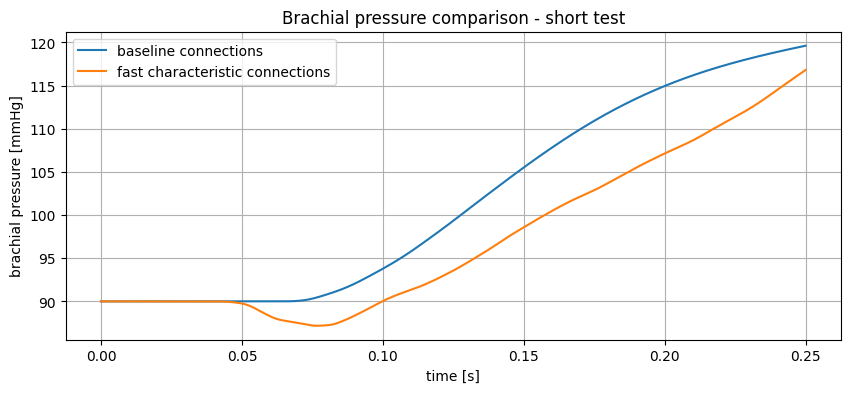

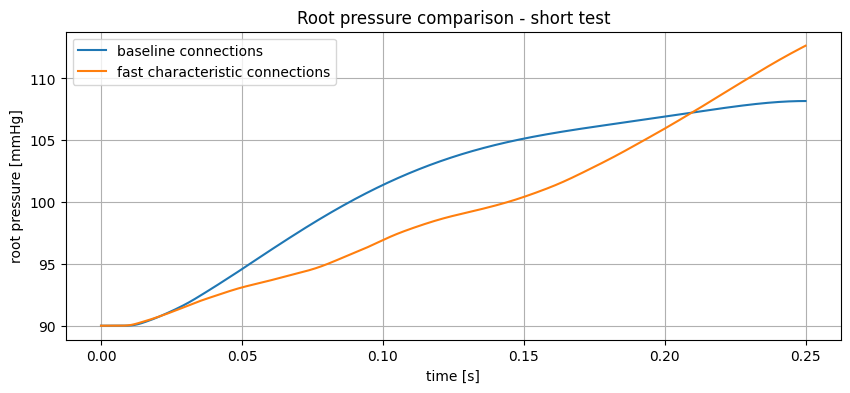

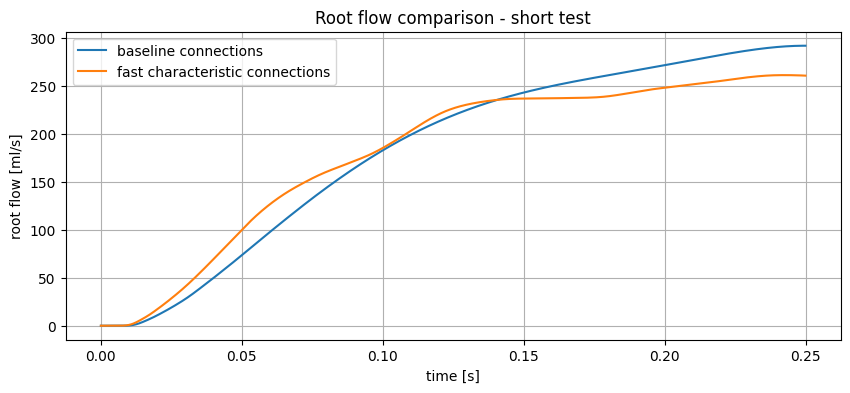

In [13]:
# COMPARE SHORT TEST: BASELINE CONNECTIONS VS FAST CHARACTERISTIC CONNECTIONS
plt.figure(figsize=(10, 4))
plt.plot(
    test_baseline_025["t"],
    test_baseline_025["p_brachial_mid"],
    label="baseline connections"
)
plt.plot(
    test_fast_conn_025["t"],
    test_fast_conn_025["p_brachial_mid"],
    label="fast characteristic connections"
)
plt.xlabel("time [s]")
plt.ylabel("brachial pressure [mmHg]")
plt.title("Brachial pressure comparison - short test")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(
    test_baseline_025["t"],
    test_baseline_025["p_root"],
    label="baseline connections"
)
plt.plot(
    test_fast_conn_025["t"],
    test_fast_conn_025["p_root"],
    label="fast characteristic connections"
)
plt.xlabel("time [s]")
plt.ylabel("root pressure [mmHg]")
plt.title("Root pressure comparison - short test")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(
    test_baseline_025["t"],
    test_baseline_025["q_root"],
    label="baseline connections"
)
plt.plot(
    test_fast_conn_025["t"],
    test_fast_conn_025["q_root"],
    label="fast characteristic connections"
)
plt.xlabel("time [s]")
plt.ylabel("root flow [ml/s]")
plt.title("Root flow comparison - short test")
plt.grid(True)
plt.legend()
plt.show()

### One-second fast-connection test

This test runs the fast characteristic connection model for a full cardiac cycle.

The purpose is to check whether the characteristic connection method remains stable beyond a very short trial and whether the brachial waveform begins to differ meaningfully from the baseline solution.

In [14]:
test_fast_conn_10 = run_solver_experiment(
    CONNECTION_MODE="fast_characteristic",
    WINDKESSEL_MODE="baseline",
    T_TEST=1.0,
    CFL_SOLVER=0.10,
    vmax=2.0,
    verbose=True,
)

record_start: 0.0
record_end: 1.0
CONNECTION_MODE: fast_characteristic
WINDKESSEL_MODE: baseline
T_TEST: 1.0
CFL_SOLVER: 0.1
dt: 3.220877998788529e-05
n_steps: 31047
ROOT: 0 ascending_aorta_C0
damping_strength: 0.0
[  3.2%] step=1000/31047 | t=0.032s | elapsed=18.9s | ETA=569.3s | max|u|=0.15 m/s | min(A/A0)=1.106 | max(A/A0)=2.137
[  6.4%] step=2000/31047 | t=0.064s | elapsed=37.3s | ETA=541.2s | max|u|=0.27 m/s | min(A/A0)=1.104 | max(A/A0)=2.183
[  9.7%] step=3000/31047 | t=0.097s | elapsed=58.9s | ETA=550.3s | max|u|=0.39 m/s | min(A/A0)=1.107 | max(A/A0)=2.233
[ 12.9%] step=4000/31047 | t=0.129s | elapsed=77.8s | ETA=525.9s | max|u|=0.48 m/s | min(A/A0)=1.102 | max(A/A0)=2.251
[ 16.1%] step=5000/31047 | t=0.161s | elapsed=97.9s | ETA=509.9s | max|u|=0.49 m/s | min(A/A0)=1.102 | max(A/A0)=2.294
[ 19.3%] step=6000/31047 | t=0.193s | elapsed=119.7s | ETA=499.8s | max|u|=0.58 m/s | min(A/A0)=1.103 | max(A/A0)=2.344
[ 22.5%] step=7000/31047 | t=0.225s | elapsed=141.6s | ETA=486.4s | ma

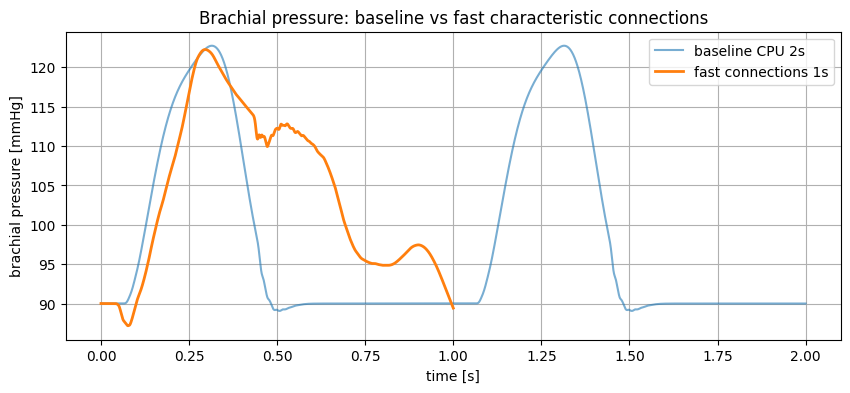

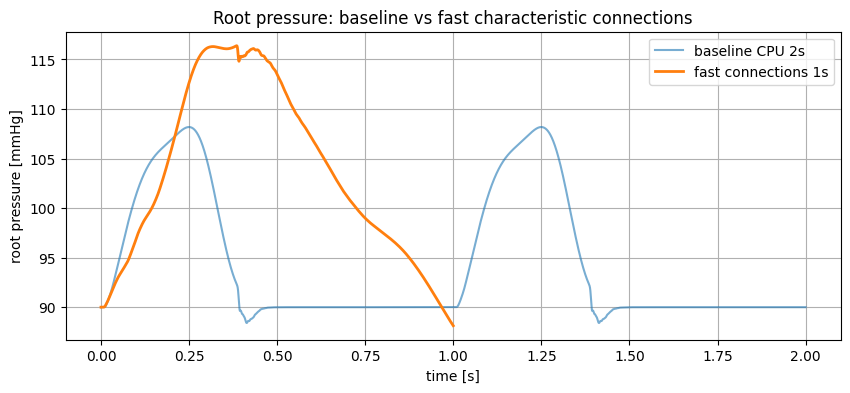

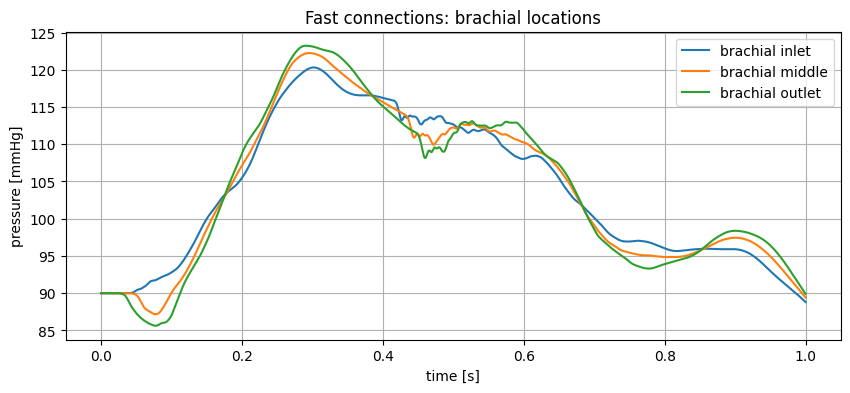

In [15]:
# COMPARE BASELINE CPU VS FAST CONNECTIONS - 1 SECOND TEST


plt.figure(figsize=(10, 4))
plt.plot(
    baseline_cpu["t"],
    baseline_cpu["p_brachial_mid"],
    label="baseline CPU 2s",
    alpha=0.6
)

plt.plot(
    test_fast_conn_10["t"],
    test_fast_conn_10["p_brachial_mid"],
    label="fast connections 1s",
    linewidth=2
)

plt.xlabel("time [s]")
plt.ylabel("brachial pressure [mmHg]")
plt.title("Brachial pressure: baseline vs fast characteristic connections")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(
    baseline_cpu["t"],
    baseline_cpu["p_root"],
    label="baseline CPU 2s",
    alpha=0.6
)

plt.plot(
    test_fast_conn_10["t"],
    test_fast_conn_10["p_root"],
    label="fast connections 1s",
    linewidth=2
)

plt.xlabel("time [s]")
plt.ylabel("root pressure [mmHg]")
plt.title("Root pressure: baseline vs fast characteristic connections")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(
    test_fast_conn_10["t"],
    test_fast_conn_10["p_brachial_in"],
    label="brachial inlet"
)
plt.plot(
    test_fast_conn_10["t"],
    test_fast_conn_10["p_brachial_mid"],
    label="brachial middle"
)
plt.plot(
    test_fast_conn_10["t"],
    test_fast_conn_10["p_brachial_out"],
    label="brachial outlet"
)

plt.xlabel("time [s]")
plt.ylabel("pressure [mmHg]")
plt.title("Fast connections: brachial locations")
plt.grid(True)
plt.legend()
plt.show()

### Fast connection plus fast characteristic Windkessel

This experiment enables both characteristic improvements:

```python
CONNECTION_MODE = "fast_characteristic"
WINDKESSEL_MODE = "fast_characteristic"

In [16]:
test_fast_conn_fast_wk_025 = run_solver_experiment(
    CONNECTION_MODE="fast_characteristic",
    WINDKESSEL_MODE="fast_characteristic",
    T_TEST=0.25,
    CFL_SOLVER=0.10,
    vmax=2.0,
    verbose=True,
)

record_start: 0.0
record_end: 0.25
CONNECTION_MODE: fast_characteristic
WINDKESSEL_MODE: fast_characteristic
T_TEST: 0.25
CFL_SOLVER: 0.1
dt: 3.220877998788529e-05
n_steps: 7761
ROOT: 0 ascending_aorta_C0
damping_strength: 0.0
[ 12.9%] step=1000/7761 | t=0.032s | elapsed=20.8s | ETA=140.9s | max|u|=0.15 m/s | min(A/A0)=1.106 | max(A/A0)=2.137
[ 25.8%] step=2000/7761 | t=0.064s | elapsed=38.9s | ETA=111.9s | max|u|=0.27 m/s | min(A/A0)=1.104 | max(A/A0)=2.183
[ 38.7%] step=3000/7761 | t=0.097s | elapsed=56.8s | ETA=90.1s | max|u|=0.39 m/s | min(A/A0)=1.107 | max(A/A0)=2.233
[ 51.5%] step=4000/7761 | t=0.129s | elapsed=76.1s | ETA=71.5s | max|u|=0.48 m/s | min(A/A0)=1.102 | max(A/A0)=2.251
[ 64.4%] step=5000/7761 | t=0.161s | elapsed=95.9s | ETA=52.9s | max|u|=0.49 m/s | min(A/A0)=1.102 | max(A/A0)=2.294
[ 77.3%] step=6000/7761 | t=0.193s | elapsed=114.9s | ETA=33.7s | max|u|=0.58 m/s | min(A/A0)=1.103 | max(A/A0)=2.344
[ 90.2%] step=7000/7761 | t=0.225s | elapsed=134.3s | ETA=14.6s | ma

In [17]:
test_fast_conn_fast_wk_10 = run_solver_experiment(
    CONNECTION_MODE="fast_characteristic",
    WINDKESSEL_MODE="fast_characteristic",
    T_TEST=1.0,
    CFL_SOLVER=0.10,
    vmax=2.0,
    verbose=True,
)

record_start: 0.0
record_end: 1.0
CONNECTION_MODE: fast_characteristic
WINDKESSEL_MODE: fast_characteristic
T_TEST: 1.0
CFL_SOLVER: 0.1
dt: 3.220877998788529e-05
n_steps: 31047
ROOT: 0 ascending_aorta_C0
damping_strength: 0.0
[  3.2%] step=1000/31047 | t=0.032s | elapsed=25.2s | ETA=757.1s | max|u|=0.15 m/s | min(A/A0)=1.106 | max(A/A0)=2.137
[  6.4%] step=2000/31047 | t=0.064s | elapsed=55.9s | ETA=812.4s | max|u|=0.27 m/s | min(A/A0)=1.104 | max(A/A0)=2.183
[  9.7%] step=3000/31047 | t=0.097s | elapsed=76.8s | ETA=718.2s | max|u|=0.39 m/s | min(A/A0)=1.107 | max(A/A0)=2.233
[ 12.9%] step=4000/31047 | t=0.129s | elapsed=95.5s | ETA=646.0s | max|u|=0.48 m/s | min(A/A0)=1.102 | max(A/A0)=2.251
[ 16.1%] step=5000/31047 | t=0.161s | elapsed=115.0s | ETA=599.2s | max|u|=0.49 m/s | min(A/A0)=1.102 | max(A/A0)=2.294
[ 19.3%] step=6000/31047 | t=0.193s | elapsed=135.8s | ETA=566.9s | max|u|=0.58 m/s | min(A/A0)=1.103 | max(A/A0)=2.344
[ 22.5%] step=7000/31047 | t=0.225s | elapsed=154.6s | ETA

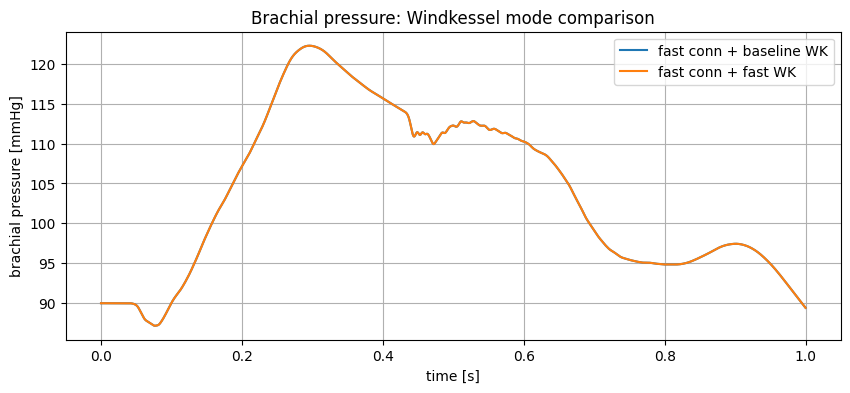

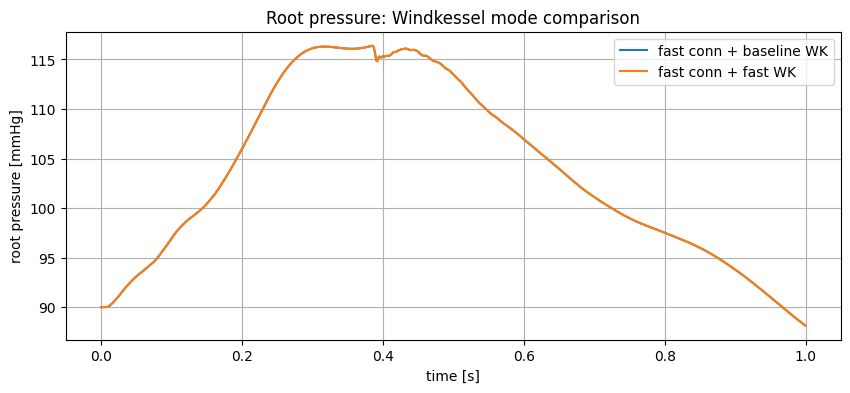

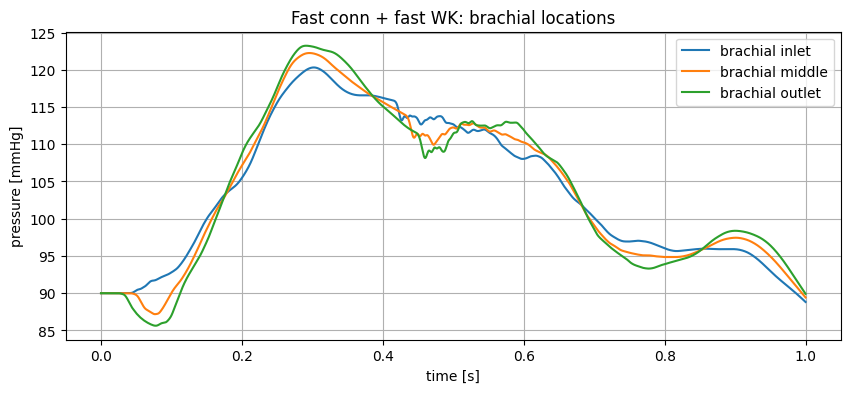

In [18]:
# COMPARE FAST CONNECTIONS: BASELINE WK VS FAST WK


plt.figure(figsize=(10, 4))
plt.plot(
    test_fast_conn_10["t"],
    test_fast_conn_10["p_brachial_mid"],
    label="fast conn + baseline WK"
)
plt.plot(
    test_fast_conn_fast_wk_10["t"],
    test_fast_conn_fast_wk_10["p_brachial_mid"],
    label="fast conn + fast WK"
)
plt.xlabel("time [s]")
plt.ylabel("brachial pressure [mmHg]")
plt.title("Brachial pressure: Windkessel mode comparison")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(
    test_fast_conn_10["t"],
    test_fast_conn_10["p_root"],
    label="fast conn + baseline WK"
)
plt.plot(
    test_fast_conn_fast_wk_10["t"],
    test_fast_conn_fast_wk_10["p_root"],
    label="fast conn + fast WK"
)
plt.xlabel("time [s]")
plt.ylabel("root pressure [mmHg]")
plt.title("Root pressure: Windkessel mode comparison")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(
    test_fast_conn_fast_wk_10["t"],
    test_fast_conn_fast_wk_10["p_brachial_in"],
    label="brachial inlet"
)
plt.plot(
    test_fast_conn_fast_wk_10["t"],
    test_fast_conn_fast_wk_10["p_brachial_mid"],
    label="brachial middle"
)
plt.plot(
    test_fast_conn_fast_wk_10["t"],
    test_fast_conn_fast_wk_10["p_brachial_out"],
    label="brachial outlet"
)
plt.xlabel("time [s]")
plt.ylabel("pressure [mmHg]")
plt.title("Fast conn + fast WK: brachial locations")
plt.grid(True)
plt.legend()
plt.show()

### Characteristic fast solver - V1

This is the first longer run using fast characteristic connections and fast characteristic Windkessel terminals.

The goal is to check whether the characteristic solver remains stable over multiple cardiac cycles and whether the pressure waveform is suitable for further tuning.

The first cycle is still affected by the artificial uniform-pressure initialization, so later versions introduce warm-up recording windows.

In [19]:
characteristic_fast_v1 = run_solver_experiment(
    CONNECTION_MODE="fast_characteristic",
    WINDKESSEL_MODE="fast_characteristic",
    T_TEST=2.0,
    CFL_SOLVER=0.10,
    vmax=2.0,
    verbose=True,
)

record_start: 0.0
record_end: 2.0
CONNECTION_MODE: fast_characteristic
WINDKESSEL_MODE: fast_characteristic
T_TEST: 2.0
CFL_SOLVER: 0.1
dt: 3.220877998788529e-05
n_steps: 62094
ROOT: 0 ascending_aorta_C0
damping_strength: 0.0
[  1.6%] step=1000/62094 | t=0.032s | elapsed=18.9s | ETA=1153.6s | max|u|=0.15 m/s | min(A/A0)=1.106 | max(A/A0)=2.137
[  3.2%] step=2000/62094 | t=0.064s | elapsed=37.5s | ETA=1126.3s | max|u|=0.27 m/s | min(A/A0)=1.104 | max(A/A0)=2.183
[  4.8%] step=3000/62094 | t=0.097s | elapsed=63.8s | ETA=1257.3s | max|u|=0.39 m/s | min(A/A0)=1.107 | max(A/A0)=2.233
[  6.4%] step=4000/62094 | t=0.129s | elapsed=85.3s | ETA=1238.2s | max|u|=0.48 m/s | min(A/A0)=1.102 | max(A/A0)=2.251
[  8.1%] step=5000/62094 | t=0.161s | elapsed=109.2s | ETA=1247.2s | max|u|=0.49 m/s | min(A/A0)=1.102 | max(A/A0)=2.294
[  9.7%] step=6000/62094 | t=0.193s | elapsed=130.5s | ETA=1219.9s | max|u|=0.58 m/s | min(A/A0)=1.103 | max(A/A0)=2.344
[ 11.3%] step=7000/62094 | t=0.225s | elapsed=155.0s

FIRST CYCLE 0-1s
Root pressure: 88.12753589446733 116.37485793403235
Root flow: -41.98960303886715 261.52095694597386
Brachial pressure: 87.18203302208163 122.24839002282106

SECOND CYCLE 1-2s
Root pressure: 87.31622237169897 115.46169355477592
Root flow: -42.071748267683745 260.59931814214764
Brachial pressure: 82.31554616827829 124.1980740564082


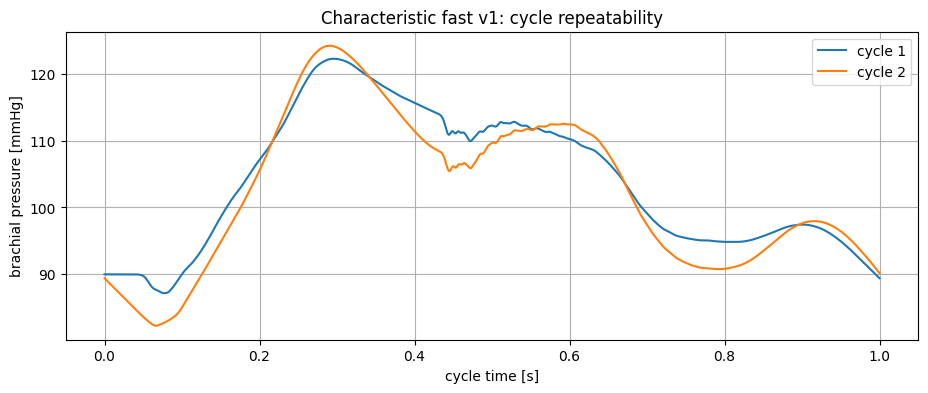

In [20]:
# CYCLE DIAGNOSTICS FOR CHARACTERISTIC FAST V1

res = characteristic_fast_v1

t = res["t"]
p_root = res["p_root"]
q_root = res["q_root"]
p_brachial = res["p_brachial"]

mask1 = (t >= 0.0) & (t < 1.0)
mask2 = (t >= 1.0) & (t < 2.0)

print("FIRST CYCLE 0-1s")
print("Root pressure:", p_root[mask1].min(), p_root[mask1].max())
print("Root flow:", q_root[mask1].min(), q_root[mask1].max())
print("Brachial pressure:", p_brachial[mask1].min(), p_brachial[mask1].max())

print("\nSECOND CYCLE 1-2s")
print("Root pressure:", p_root[mask2].min(), p_root[mask2].max())
print("Root flow:", q_root[mask2].min(), q_root[mask2].max())
print("Brachial pressure:", p_brachial[mask2].min(), p_brachial[mask2].max())

plt.figure(figsize=(11, 4))
plt.plot(t[mask1], p_brachial[mask1], label="cycle 1")
plt.plot(t[mask2] - 1.0, p_brachial[mask2], label="cycle 2")
plt.xlabel("cycle time [s]")
plt.ylabel("brachial pressure [mmHg]")
plt.title("Characteristic fast v1: cycle repeatability")
plt.grid(True)
plt.legend()
plt.show()

In [21]:
# SAVE CHARACTERISTIC FAST V1
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

characteristic_fast_v1["description"] = (
    "ADAN-86 CPU solver with fast linearized characteristic connections "
    "and fast local-characteristic Windkessel terminals. "
    "Stable 2-second run, CFL=0.10."
)

characteristic_fast_v1["validation_note"] = (
    "Stable run without NaN and without Windkessel clamp hits. "
    "Cycle 2 shows slightly lower brachial diastolic pressure than cycle 1, "
    "so for final production consider a longer warm-up and export last cycles."
)

output_path = RESULTS_DIR / "characteristic_fast_conn_fast_wk_cfl01_v1.pkl"

with open(output_path, "wb") as f:
    pickle.dump(characteristic_fast_v1, f)

print("Saved:", output_path.resolve())
print("File size MB:", output_path.stat().st_size / 1024 / 1024)

Saved: D:\code\adan_project\NBS\results\characteristic_fast_conn_fast_wk_cfl01_v1.pkl
File size MB: 9.681386947631836


### Characteristic fast solver - V2 with warm-up

This version runs for three seconds but records only after the first second.

The purpose is to reduce the effect of the initial transient caused by starting from a uniform pressure field.

The recorded waveform should therefore better represent the solver's repeating behaviour after the network has already been excited by at least one cardiac cycle.

In [22]:
characteristic_fast_warmup_v2 = run_solver_experiment(
    CONNECTION_MODE="fast_characteristic",
    WINDKESSEL_MODE="fast_characteristic",
    T_TEST=3.0,
    CFL_SOLVER=0.10,
    vmax=2.0,
    snapshot_dt=0.01,
    record_start=1.0,
    record_end=3.0,
    verbose=True,
)

record_start: 1.0
record_end: 3.0
CONNECTION_MODE: fast_characteristic
WINDKESSEL_MODE: fast_characteristic
T_TEST: 3.0
CFL_SOLVER: 0.1
dt: 3.220877998788529e-05
n_steps: 93142
ROOT: 0 ascending_aorta_C0
damping_strength: 0.0
[  1.1%] step=1000/93142 | t=0.032s | elapsed=22.3s | ETA=2051.8s | max|u|=0.15 m/s | min(A/A0)=1.106 | max(A/A0)=2.137
[  2.1%] step=2000/93142 | t=0.064s | elapsed=46.6s | ETA=2125.3s | max|u|=0.27 m/s | min(A/A0)=1.104 | max(A/A0)=2.183
[  3.2%] step=3000/93142 | t=0.097s | elapsed=72.1s | ETA=2165.2s | max|u|=0.39 m/s | min(A/A0)=1.107 | max(A/A0)=2.233
[  4.3%] step=4000/93142 | t=0.129s | elapsed=94.2s | ETA=2098.6s | max|u|=0.48 m/s | min(A/A0)=1.102 | max(A/A0)=2.251
[  5.4%] step=5000/93142 | t=0.161s | elapsed=121.6s | ETA=2142.8s | max|u|=0.49 m/s | min(A/A0)=1.102 | max(A/A0)=2.294
[  6.4%] step=6000/93142 | t=0.193s | elapsed=142.3s | ETA=2066.8s | max|u|=0.58 m/s | min(A/A0)=1.103 | max(A/A0)=2.344
[  7.5%] step=7000/93142 | t=0.225s | elapsed=165.2s

RECORDED CYCLE 1
Root pressure: 87.31438566807469 115.46169355477592
Root flow: -42.071748267683745 260.59931814214764
Brachial pressure: 82.31554616827829 124.1980740564082

RECORDED CYCLE 2
Root pressure: 86.77222477175141 114.82227046113441
Root flow: -40.46048752837675 259.88418299064824
Brachial pressure: 80.25175508256108 125.50897838926184


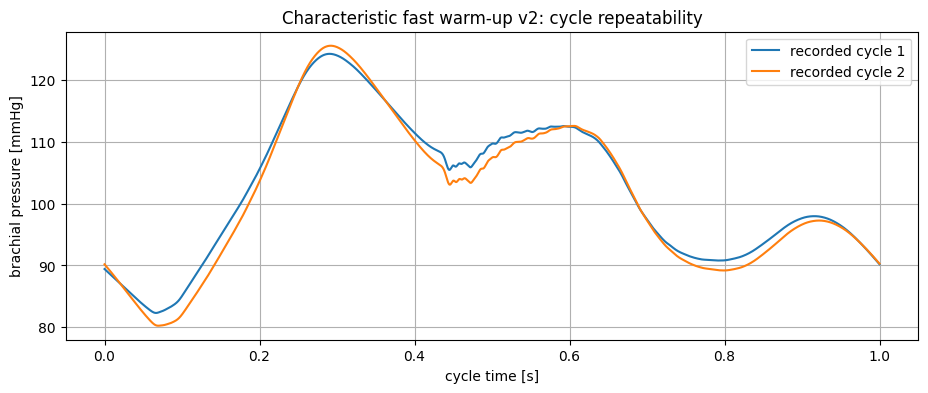

In [23]:
res = characteristic_fast_warmup_v2

t = res["t"]
p_root = res["p_root"]
q_root = res["q_root"]
p_brachial = res["p_brachial"]

mask1 = (t >= 0.0) & (t < 1.0)
mask2 = (t >= 1.0) & (t < 2.0)

print("RECORDED CYCLE 1")
print("Root pressure:", p_root[mask1].min(), p_root[mask1].max())
print("Root flow:", q_root[mask1].min(), q_root[mask1].max())
print("Brachial pressure:", p_brachial[mask1].min(), p_brachial[mask1].max())

print("\nRECORDED CYCLE 2")
print("Root pressure:", p_root[mask2].min(), p_root[mask2].max())
print("Root flow:", q_root[mask2].min(), q_root[mask2].max())
print("Brachial pressure:", p_brachial[mask2].min(), p_brachial[mask2].max())

plt.figure(figsize=(11, 4))
plt.plot(t[mask1], p_brachial[mask1], label="recorded cycle 1")
plt.plot(t[mask2] - 1.0, p_brachial[mask2], label="recorded cycle 2")
plt.xlabel("cycle time [s]")
plt.ylabel("brachial pressure [mmHg]")
plt.title("Characteristic fast warm-up v2: cycle repeatability")
plt.grid(True)
plt.legend()
plt.show()

In [24]:
# SAVE CHARACTERISTIC FAST WARMUP V2

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

characteristic_fast_warmup_v2["description"] = (
    "ADAN-86 CPU solver with fast linearized characteristic connections "
    "and fast local-characteristic Windkessel terminals. "
    "3-second simulation with first 1 second used as warm-up; "
    "recorded output window is 1–3 s."
)

characteristic_fast_warmup_v2["record_start"] = 1.0
characteristic_fast_warmup_v2["record_end"] = 3.0

output_path = RESULTS_DIR / "characteristic_fast_warmup_record_last2s_cfl01_v2.pkl"

with open(output_path, "wb") as f:
    pickle.dump(characteristic_fast_warmup_v2, f)

print("Saved:", output_path.resolve())
print("File size MB:", output_path.stat().st_size / 1024 / 1024)

Saved: D:\code\adan_project\NBS\results\characteristic_fast_warmup_record_last2s_cfl01_v2.pkl
File size MB: 9.681280136108398


### Characteristic fast solver - V3 with longer warm-up

This version runs for four seconds and records only after two seconds.

The goal is to give the network more time to settle before evaluating the waveform.


In [25]:
characteristic_fast_warmup_v3 = run_solver_experiment(
    CONNECTION_MODE="fast_characteristic",
    WINDKESSEL_MODE="fast_characteristic",
    T_TEST=4.0,
    CFL_SOLVER=0.10,
    vmax=2.0,
    snapshot_dt=0.01,
    record_start=2.0,
    record_end=4.0,
    verbose=True,
)

record_start: 2.0
record_end: 4.0
CONNECTION_MODE: fast_characteristic
WINDKESSEL_MODE: fast_characteristic
T_TEST: 4.0
CFL_SOLVER: 0.1
dt: 3.220877998788529e-05
n_steps: 124189
ROOT: 0 ascending_aorta_C0
damping_strength: 0.0
[  0.8%] step=1000/124189 | t=0.032s | elapsed=18.0s | ETA=2218.1s | max|u|=0.15 m/s | min(A/A0)=1.106 | max(A/A0)=2.137
[  1.6%] step=2000/124189 | t=0.064s | elapsed=35.9s | ETA=2190.8s | max|u|=0.27 m/s | min(A/A0)=1.104 | max(A/A0)=2.183
[  2.4%] step=3000/124189 | t=0.097s | elapsed=53.9s | ETA=2178.2s | max|u|=0.39 m/s | min(A/A0)=1.107 | max(A/A0)=2.233
[  3.2%] step=4000/124189 | t=0.129s | elapsed=73.5s | ETA=2209.7s | max|u|=0.48 m/s | min(A/A0)=1.102 | max(A/A0)=2.251
[  4.0%] step=5000/124189 | t=0.161s | elapsed=91.2s | ETA=2173.5s | max|u|=0.49 m/s | min(A/A0)=1.102 | max(A/A0)=2.294
[  4.8%] step=6000/124189 | t=0.193s | elapsed=109.4s | ETA=2155.1s | max|u|=0.58 m/s | min(A/A0)=1.103 | max(A/A0)=2.344
[  5.6%] step=7000/124189 | t=0.225s | elapsed

RECORDED CYCLE 1
Root pressure: 86.77222477175141 114.82227046113441
Root flow: -40.46048752837675 259.88418299064824
Brachial pressure: 80.25175508256108 125.50897838926184

RECORDED CYCLE 2
Root pressure: 86.29515622571505 114.30619923186953
Root flow: -40.03260850630098 259.5348920853275
Brachial pressure: 79.97711825790944 125.07153345696558


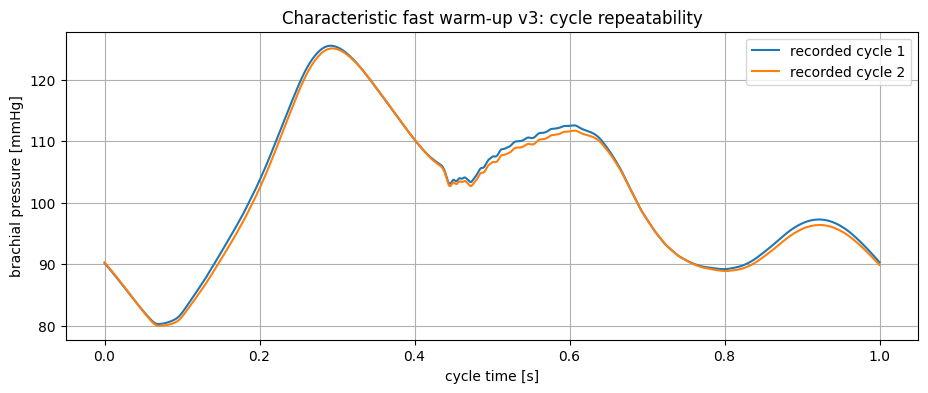

In [26]:
# CYCLE DIAGNOSTICS FOR CHARACTERISTIC FAST WARMUP V3

res = characteristic_fast_warmup_v3

t = res["t"]
p_root = res["p_root"]
q_root = res["q_root"]
p_brachial = res["p_brachial"]

mask1 = (t >= 0.0) & (t < 1.0)
mask2 = (t >= 1.0) & (t < 2.0)

print("RECORDED CYCLE 1")
print("Root pressure:", p_root[mask1].min(), p_root[mask1].max())
print("Root flow:", q_root[mask1].min(), q_root[mask1].max())
print("Brachial pressure:", p_brachial[mask1].min(), p_brachial[mask1].max())

print("\nRECORDED CYCLE 2")
print("Root pressure:", p_root[mask2].min(), p_root[mask2].max())
print("Root flow:", q_root[mask2].min(), q_root[mask2].max())
print("Brachial pressure:", p_brachial[mask2].min(), p_brachial[mask2].max())

plt.figure(figsize=(11, 4))
plt.plot(t[mask1], p_brachial[mask1], label="recorded cycle 1")
plt.plot(t[mask2] - 1.0, p_brachial[mask2], label="recorded cycle 2")
plt.xlabel("cycle time [s]")
plt.ylabel("brachial pressure [mmHg]")
plt.title("Characteristic fast warm-up v3: cycle repeatability")
plt.grid(True)
plt.legend()
plt.show()

In [27]:
# SAVE CHARACTERISTIC FAST WARMUP V3
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

characteristic_fast_warmup_v3["description"] = (
    "ADAN-86 CPU solver with fast linearized characteristic connections "
    "and fast local-characteristic Windkessel terminals. "
    "4-second simulation with first 2 seconds used as warm-up; "
    "recorded output window is 2–4 s."
)

characteristic_fast_warmup_v3["record_start"] = 2.0
characteristic_fast_warmup_v3["record_end"] = 4.0
characteristic_fast_warmup_v3["version"] = "v3_warmup_last2s"
characteristic_fast_warmup_v3["recommended_for_animation"] = True

output_path = RESULTS_DIR / "characteristic_fast_warmup_record_last2s_cfl01_v3.pkl"

with open(output_path, "wb") as f:
    pickle.dump(characteristic_fast_warmup_v3, f)

print("Saved:", output_path.resolve())
print("File size MB:", output_path.stat().st_size / 1024 / 1024)

Saved: D:\code\adan_project\NBS\results\characteristic_fast_warmup_record_last2s_cfl01_v3.pkl
File size MB: 9.681336402893066


### Damping experiment

The characteristic solver can produce persistent reflected oscillations.

This section tests whether adding simple flow damping improves the brachial waveform.

The damping term is not intended as a final physiological friction model.  
It is a controlled experiment to see whether modest energy loss produces a cleaner peripheral pressure trace.

In [28]:
test_fast_damp_10 = run_solver_experiment(
    CONNECTION_MODE="fast_characteristic",
    WINDKESSEL_MODE="fast_characteristic",
    T_TEST=1.0,
    CFL_SOLVER=0.10,
    vmax=2.0,
    snapshot_dt=0.01,
    record_start=0.0,
    record_end=1.0,
    damping_strength=0.5,
    verbose=True,
)

record_start: 0.0
record_end: 1.0
CONNECTION_MODE: fast_characteristic
WINDKESSEL_MODE: fast_characteristic
T_TEST: 1.0
CFL_SOLVER: 0.1
dt: 3.220877998788529e-05
n_steps: 31047
ROOT: 0 ascending_aorta_C0
damping_strength: 0.5
[  3.2%] step=1000/31047 | t=0.032s | elapsed=22.5s | ETA=676.4s | max|u|=0.14 m/s | min(A/A0)=1.106 | max(A/A0)=2.137
[  6.4%] step=2000/31047 | t=0.064s | elapsed=48.8s | ETA=708.8s | max|u|=0.26 m/s | min(A/A0)=1.103 | max(A/A0)=2.183
[  9.7%] step=3000/31047 | t=0.097s | elapsed=72.6s | ETA=678.5s | max|u|=0.38 m/s | min(A/A0)=1.106 | max(A/A0)=2.233
[ 12.9%] step=4000/31047 | t=0.129s | elapsed=97.1s | ETA=656.5s | max|u|=0.47 m/s | min(A/A0)=1.103 | max(A/A0)=2.253
[ 16.1%] step=5000/31047 | t=0.161s | elapsed=121.1s | ETA=630.8s | max|u|=0.47 m/s | min(A/A0)=1.100 | max(A/A0)=2.295
[ 19.3%] step=6000/31047 | t=0.193s | elapsed=141.0s | ETA=588.7s | max|u|=0.56 m/s | min(A/A0)=1.101 | max(A/A0)=2.347
[ 22.5%] step=7000/31047 | t=0.225s | elapsed=167.7s | ETA

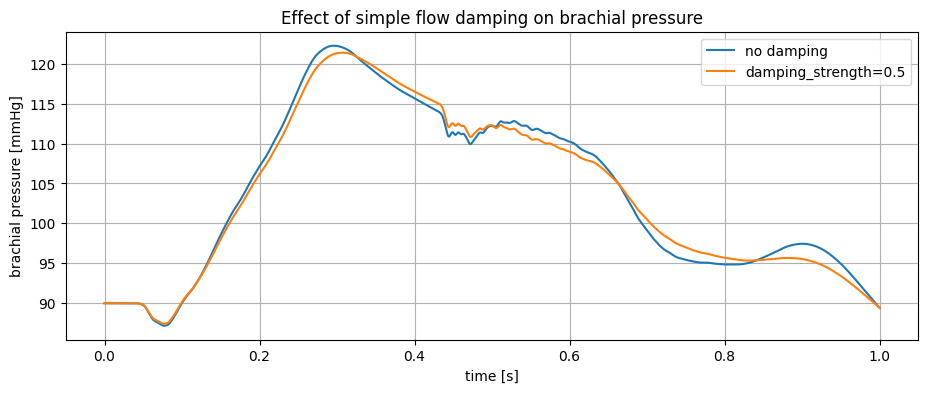

In [29]:
plt.figure(figsize=(11, 4))
plt.plot(
    test_fast_conn_fast_wk_10["t"],
    test_fast_conn_fast_wk_10["p_brachial_mid"],
    label="no damping"
)
plt.plot(
    test_fast_damp_10["t"],
    test_fast_damp_10["p_brachial_mid"],
    label="damping_strength=0.5"
)
plt.xlabel("time [s]")
plt.ylabel("brachial pressure [mmHg]")
plt.title("Effect of simple flow damping on brachial pressure")
plt.grid(True)
plt.legend()
plt.show()

### Damping strength sweep

Here we compare different values of `damping_strength`.

The goal is to find a damping level that reduces unrealistic oscillations without flattening the physiological pressure waveform too much.

A useful damping value should:

- preserve the systolic upstroke
- keep a visible peripheral pressure pulse
- reduce excessive high-frequency ringing
- avoid collapsing pulse pressure

In [30]:
test_fast_damp_025_10 = run_solver_experiment(
    CONNECTION_MODE="fast_characteristic",
    WINDKESSEL_MODE="fast_characteristic",
    T_TEST=1.0,
    CFL_SOLVER=0.10,
    vmax=2.0,
    snapshot_dt=0.01,
    record_start=0.0,
    record_end=1.0,
    damping_strength=0.25,
    verbose=True,
)

record_start: 0.0
record_end: 1.0
CONNECTION_MODE: fast_characteristic
WINDKESSEL_MODE: fast_characteristic
T_TEST: 1.0
CFL_SOLVER: 0.1
dt: 3.220877998788529e-05
n_steps: 31047
ROOT: 0 ascending_aorta_C0
damping_strength: 0.25
[  3.2%] step=1000/31047 | t=0.032s | elapsed=16.0s | ETA=480.3s | max|u|=0.14 m/s | min(A/A0)=1.106 | max(A/A0)=2.137
[  6.4%] step=2000/31047 | t=0.064s | elapsed=32.6s | ETA=473.5s | max|u|=0.26 m/s | min(A/A0)=1.103 | max(A/A0)=2.183
[  9.7%] step=3000/31047 | t=0.097s | elapsed=48.6s | ETA=454.6s | max|u|=0.38 m/s | min(A/A0)=1.107 | max(A/A0)=2.233
[ 12.9%] step=4000/31047 | t=0.129s | elapsed=64.5s | ETA=436.2s | max|u|=0.48 m/s | min(A/A0)=1.102 | max(A/A0)=2.252
[ 16.1%] step=5000/31047 | t=0.161s | elapsed=81.7s | ETA=425.6s | max|u|=0.47 m/s | min(A/A0)=1.101 | max(A/A0)=2.295
[ 19.3%] step=6000/31047 | t=0.193s | elapsed=100.1s | ETA=417.8s | max|u|=0.57 m/s | min(A/A0)=1.102 | max(A/A0)=2.345
[ 22.5%] step=7000/31047 | t=0.225s | elapsed=116.9s | ETA

In [31]:
test_fast_damp_100_10 = run_solver_experiment(
    CONNECTION_MODE="fast_characteristic",
    WINDKESSEL_MODE="fast_characteristic",
    T_TEST=1.0,
    CFL_SOLVER=0.10,
    vmax=2.0,
    snapshot_dt=0.01,
    record_start=0.0,
    record_end=1.0,
    damping_strength=1.0,
    verbose=True,
)

record_start: 0.0
record_end: 1.0
CONNECTION_MODE: fast_characteristic
WINDKESSEL_MODE: fast_characteristic
T_TEST: 1.0
CFL_SOLVER: 0.1
dt: 3.220877998788529e-05
n_steps: 31047
ROOT: 0 ascending_aorta_C0
damping_strength: 1.0
[  3.2%] step=1000/31047 | t=0.032s | elapsed=20.2s | ETA=605.9s | max|u|=0.14 m/s | min(A/A0)=1.105 | max(A/A0)=2.137
[  6.4%] step=2000/31047 | t=0.064s | elapsed=40.9s | ETA=593.3s | max|u|=0.25 m/s | min(A/A0)=1.102 | max(A/A0)=2.183
[  9.7%] step=3000/31047 | t=0.097s | elapsed=61.2s | ETA=572.3s | max|u|=0.38 m/s | min(A/A0)=1.103 | max(A/A0)=2.233
[ 12.9%] step=4000/31047 | t=0.129s | elapsed=79.1s | ETA=535.0s | max|u|=0.47 m/s | min(A/A0)=1.103 | max(A/A0)=2.254
[ 16.1%] step=5000/31047 | t=0.161s | elapsed=100.9s | ETA=525.7s | max|u|=0.47 m/s | min(A/A0)=1.098 | max(A/A0)=2.297
[ 19.3%] step=6000/31047 | t=0.193s | elapsed=126.5s | ETA=528.1s | max|u|=0.55 m/s | min(A/A0)=1.100 | max(A/A0)=2.349
[ 22.5%] step=7000/31047 | t=0.225s | elapsed=150.3s | ETA

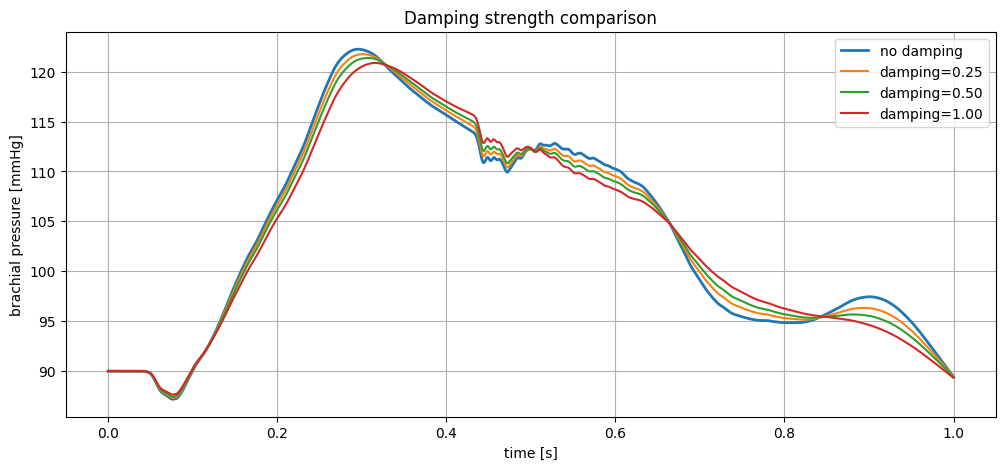

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_fast_conn_fast_wk_10["t"],
    test_fast_conn_fast_wk_10["p_brachial_mid"],
    label="no damping",
    linewidth=2
)

plt.plot(
    test_fast_damp_025_10["t"],
    test_fast_damp_025_10["p_brachial_mid"],
    label="damping=0.25"
)

plt.plot(
    test_fast_damp_10["t"],
    test_fast_damp_10["p_brachial_mid"],
    label="damping=0.50"
)

plt.plot(
    test_fast_damp_100_10["t"],
    test_fast_damp_100_10["p_brachial_mid"],
    label="damping=1.00"
)

plt.xlabel("time [s]")
plt.ylabel("brachial pressure [mmHg]")
plt.title("Damping strength comparison")
plt.grid(True)
plt.legend()
plt.show()

### Characteristic fast damped solver - V4

This is the final tested variant in this notebook.

It uses:

```python
CONNECTION_MODE = "fast_characteristic"
WINDKESSEL_MODE = "fast_characteristic"
damping_strength > 0

In [33]:
characteristic_fast_damped_v4 = run_solver_experiment(
    CONNECTION_MODE="fast_characteristic",
    WINDKESSEL_MODE="fast_characteristic",
    T_TEST=4.0,
    CFL_SOLVER=0.10,
    vmax=2.0,
    snapshot_dt=0.01,
    record_start=2.0,
    record_end=4.0,
    damping_strength=0.5,
    verbose=True,
)

record_start: 2.0
record_end: 4.0
CONNECTION_MODE: fast_characteristic
WINDKESSEL_MODE: fast_characteristic
T_TEST: 4.0
CFL_SOLVER: 0.1
dt: 3.220877998788529e-05
n_steps: 124189
ROOT: 0 ascending_aorta_C0
damping_strength: 0.5
[  0.8%] step=1000/124189 | t=0.032s | elapsed=26.7s | ETA=3286.1s | max|u|=0.14 m/s | min(A/A0)=1.106 | max(A/A0)=2.137
[  1.6%] step=2000/124189 | t=0.064s | elapsed=52.9s | ETA=3231.4s | max|u|=0.26 m/s | min(A/A0)=1.103 | max(A/A0)=2.183
[  2.4%] step=3000/124189 | t=0.097s | elapsed=81.2s | ETA=3282.0s | max|u|=0.38 m/s | min(A/A0)=1.106 | max(A/A0)=2.233
[  3.2%] step=4000/124189 | t=0.129s | elapsed=109.4s | ETA=3286.1s | max|u|=0.47 m/s | min(A/A0)=1.103 | max(A/A0)=2.253
[  4.0%] step=5000/124189 | t=0.161s | elapsed=137.5s | ETA=3278.8s | max|u|=0.47 m/s | min(A/A0)=1.100 | max(A/A0)=2.295
[  4.8%] step=6000/124189 | t=0.193s | elapsed=161.4s | ETA=3179.3s | max|u|=0.56 m/s | min(A/A0)=1.101 | max(A/A0)=2.347
[  5.6%] step=7000/124189 | t=0.225s | elaps

# Final cycle diagnostics

This section evaluates the final selected characteristic solver variant.

The diagnostics inspect:

- root pressure range
- root flow range
- brachial pressure range
- first recorded cycle
- second recorded cycle
- whether the waveform remains stable after warm-up

The key question is whether the brachial waveform is plausible enough to use as the live waveform panel in the final animation.

RECORDED CYCLE 1
Root pressure: 86.9554317371946 114.87715517654678
Root flow: -41.10245219516615 260.3944067053591
Brachial pressure: 82.98785606407431 121.54122982236234

RECORDED CYCLE 2
Root pressure: 86.47779992335906 114.37171924977719
Root flow: -41.001426522296754 260.19715481317877
Brachial pressure: 82.4881276929253 121.19351030903216


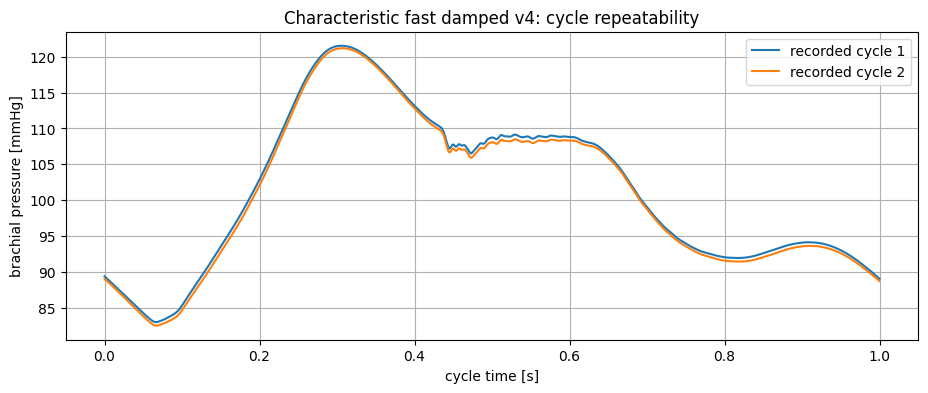

In [34]:
# CYCLE DIAGNOSTICS FOR CHARACTERISTIC FAST DAMPED V4

res = characteristic_fast_damped_v4

t = res["t"]
p_root = res["p_root"]
q_root = res["q_root"]
p_brachial = res["p_brachial"]

mask1 = (t >= 0.0) & (t < 1.0)
mask2 = (t >= 1.0) & (t < 2.0)

print("RECORDED CYCLE 1")
print("Root pressure:", p_root[mask1].min(), p_root[mask1].max())
print("Root flow:", q_root[mask1].min(), q_root[mask1].max())
print("Brachial pressure:", p_brachial[mask1].min(), p_brachial[mask1].max())

print("\nRECORDED CYCLE 2")
print("Root pressure:", p_root[mask2].min(), p_root[mask2].max())
print("Root flow:", q_root[mask2].min(), q_root[mask2].max())
print("Brachial pressure:", p_brachial[mask2].min(), p_brachial[mask2].max())

plt.figure(figsize=(11, 4))
plt.plot(t[mask1], p_brachial[mask1], label="recorded cycle 1")
plt.plot(t[mask2] - 1.0, p_brachial[mask2], label="recorded cycle 2")
plt.xlabel("cycle time [s]")
plt.ylabel("brachial pressure [mmHg]")
plt.title("Characteristic fast damped v4: cycle repeatability")
plt.grid(True)
plt.legend()
plt.show()

## Compare undamped and damped characteristic solver

This comparison shows the effect of damping on the right brachial pressure waveform.

The undamped characteristic solver can preserve too much reflected wave energy, which may create non-physiological oscillations.

The damped version should ideally keep the main pulse shape while reducing excessive ringing.

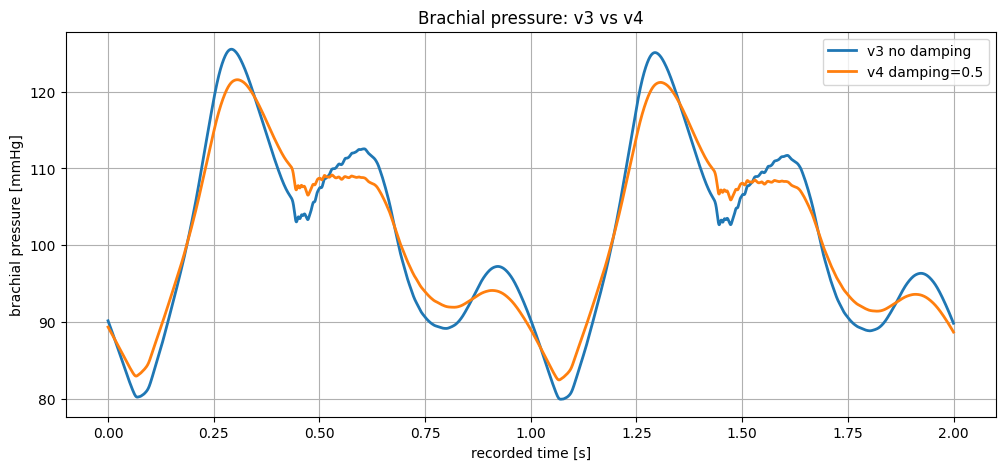

In [35]:
# COMPARE V3 NO DAMPING VS V4 DAMPED
plt.figure(figsize=(12, 5))

plt.plot(
    characteristic_fast_warmup_v3["t"],
    characteristic_fast_warmup_v3["p_brachial_mid"],
    label="v3 no damping",
    linewidth=2
)

plt.plot(
    characteristic_fast_damped_v4["t"],
    characteristic_fast_damped_v4["p_brachial_mid"],
    label="v4 damping=0.5",
    linewidth=2
)

plt.xlabel("recorded time [s]")
plt.ylabel("brachial pressure [mmHg]")
plt.title("Brachial pressure: v3 vs v4")
plt.grid(True)
plt.legend()
plt.show()

## Save selected characteristic solver result

This block is intended to save the final selected characteristic solver output.

At this stage, the best candidate is the damped V4 solver.

The saved result should include:

- root waveform
- brachial waveform
- selected vessel waveforms
- pressure snapshots
- final area and flow fields
- final Windkessel capacitor pressures
- validation metrics


In [36]:
# SAVE CHARACTERISTIC FAST DAMPED V4
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

characteristic_fast_damped_v4["description"] = (
    "ADAN-86 CPU solver with fast linearized characteristic connections, "
    "fast local-characteristic Windkessel terminals, and simple radius-scaled "
    "flow damping. 4-second simulation with first 2 seconds used as warm-up; "
    "recorded output window is 2–4 s."
)

characteristic_fast_damped_v4["record_start"] = 2.0
characteristic_fast_damped_v4["record_end"] = 4.0
characteristic_fast_damped_v4["damping_strength"] = 0.5
characteristic_fast_damped_v4["version"] = "v4_damped_warmup_last2s"
characteristic_fast_damped_v4["recommended_for_animation"] = True

output_path = RESULTS_DIR / "characteristic_fast_damped_record_last2s_cfl01_v4.pkl"

with open(output_path, "wb") as f:
    pickle.dump(characteristic_fast_damped_v4, f)

print("Saved:", output_path.resolve())
print("File size MB:", output_path.stat().st_size / 1024 / 1024)

Saved: D:\code\adan_project\NBS\results\characteristic_fast_damped_record_last2s_cfl01_v4.pkl
File size MB: 9.681377410888672
